# Dựng model từ dataset Customer_Behaviour để dự đoán khả năng mua hàng

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

In [ ]:
# Danh sách tên cột (header)
file_path = '/content/Customer_Behaviour.csv'
col_names = ['user_id', 'gender', 'age', 'estimated', 'purchased']

df = pd.read_csv(file_path,header=None, names=col_names)

df = df.drop(index=0)

# Hiển thị 5 dòng đầu
print(df.head())

# Thông tin cấu trúc của dữ liệu
df.info()

: 

In [ ]:
# Hiển thị bảng dữ liệu
from IPython.display import display
display(df.head())

,user_id,gender,age,estimated,purchased
1,15624510,Male,19,19000,0
2,15810944,Male,35,20000,0
3,15668575,Female,26,43000,0
4,15603246,Female,27,57000,0
5,15804002,Male,19,76000,0


## Trực quan hóa dữ liệu trong tập ban đầu

In [ ]:
# Định nghĩa các khoảng giá trị và nhãn
bins = [0, 50000, float('inf')] #Updated to create 2 bins
labels = ['<=50k', '>50k']  # Your desired labels

# Chuyển đổi cột 'estimated' thành kiểu số (numeric)
df['estimated'] = pd.to_numeric(df['estimated'], errors='coerce')
# errors='coerce' sẽ chuyển đổi các giá trị không hợp lệ thành NaN

# Thêm cột mới với phân loại
df['estimated_category'] = pd.cut(df['estimated'], bins=bins, labels=labels, right=False, include_lowest=True, duplicates='drop')

# Hiển thị 5 dòng đầu
print(df[['estimated', 'estimated_category']].head())

# Thống kê số lượng mỗi nhóm
print(df['estimated_category'].value_counts())

   estimated estimated_category
1      19000              <=50k
2      20000              <=50k
3      43000              <=50k
4      57000               >50k
5      76000               >50k
estimated_category
>50k     282
<=50k    118
Name: count, dtype: int64


## So sánh độ tương quan của Estimated so với Purchased
### Kết luận tổng quan:
- Tỷ lệ mua hàng tăng đáng kể ở nhóm có thu nhập cao nhất (>100k). Điều này cho thấy có một mối tương quan giữa thu nhập cao và khả năng mua hàng.
- Nhóm thu nhập trung bình (50-75k) lại có tỷ lệ mua hàng thấp hơn đáng kể, có thể do các yếu tố khác ảnh hưởng như nhu cầu hoặc sở thích.

### Chi tiết:
- Nhóm thu nhập từ 50k -> 75k vẫn chiếm đa số nhưng lại là nhòm quyết định mua hàng thấp nhất theo tổng số.
- Nhóm thu nhập dưới 25k có số lượng thấp nhất vậy nên có số lượng mua theo tổng số cao hơn nhóm thu nhập 50k -> 75k
- Nhóm thu nhập 25->50k và 75->100k có số lương tương đương về lượt mua cũng như tổng số
- Nhóm thu nhập >100k có số lượng mua cao nhất về số lượng cũng như phần trăm mua theo tổng số
- Việc thiếu dữ liệu ("?") cho thấy có thể có vấn đề trong việc thu thập hoặc phân loại thông tin của nhóm lao động này.


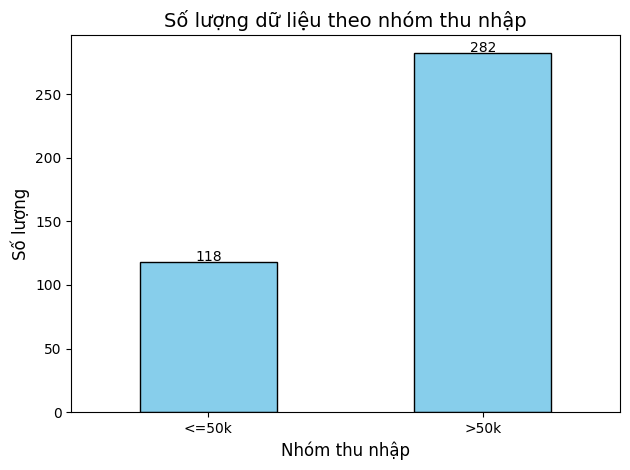

In [ ]:
import matplotlib.pyplot as plt

# Đảm bảo cột 'estimated_category' được sắp xếp theo thứ tự xác định
df['estimated_category'] = pd.Categorical(
    df['estimated_category'],
    categories=['<=50k', '>50k'],
    ordered=True
)

# Đếm số lượng dữ liệu trong từng nhóm
category_counts = df['estimated_category'].value_counts(sort=False)

# Tạo biểu đồ cột
ax = category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(category_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo nhóm thu nhập', fontsize=14)
plt.xlabel('Nhóm thu nhập', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đảm bảo cột 'estimated_category' được sắp xếp theo thứ tự xác định
df['estimated_category'] = pd.Categorical(
    df['estimated_category'],
    categories=['<=50k', '>50k'],
    ordered=True
)

# Thống kê số lượng mỗi nhóm `estimated_category` theo `purchased`
summary = df.groupby(['estimated_category', 'purchased'], observed=False).size().unstack(fill_value=0)

print("Thống kê số lượng mỗi nhóm theo purchased:")
print(summary)

# Tính tỷ lệ phần trăm cho từng nhóm
summary_percentage = (summary.T / summary.sum(axis=1) * 100).T

print("\nTỷ lệ phần trăm mỗi nhóm theo purchased:")
print(summary_percentage)

Thống kê số lượng mỗi nhóm theo purchased:
purchased             0    1
estimated_category          
<=50k                75   43
>50k                182  100

Tỷ lệ phần trăm mỗi nhóm theo purchased:
purchased                   0          1
estimated_category                      
<=50k               63.559322  36.440678
>50k                64.539007  35.460993


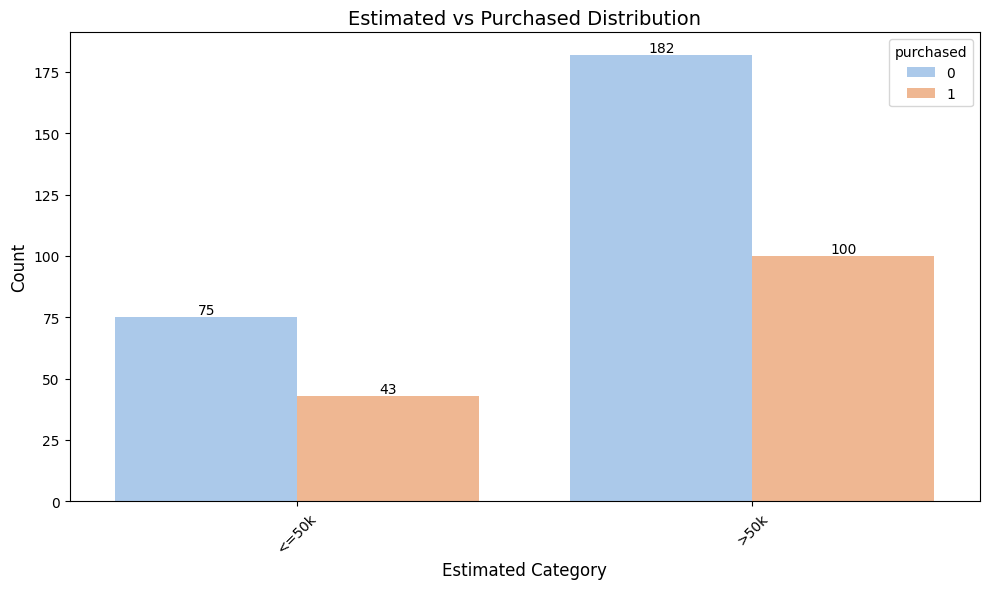

In [ ]:
# Tạo biểu đồ
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='estimated_category', hue='purchased', palette='pastel')
plt.xticks(rotation=45)
plt.title('Estimated vs Purchased Distribution', fontsize=14)
plt.xlabel('Estimated Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Thêm số lượng trên mỗi cột
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Kết luận tổng quan
1. Xu hướng chung: Tỷ lệ mua hàng tăng theo độ tuổi.
- Nhóm trẻ (18-30) ít có khả năng mua hàng.
- Nhóm lớn tuổi (50-60) gần như ngược lại, với tỷ lệ mua hàng cao nhất.
2. Nhóm cần chú ý:
- 40-50 tuổi: Đây là nhóm có sự cân bằng giữa mua và không mua, cho thấy tiềm năng lớn nếu chiến lược tập trung đúng vào nhóm này.
- 50-60 tuổi: Nhóm tuổi cao nhất có quyết định mua hàng nhanh và ổn định..

## Chi tiết
1. Nhóm 18-30:
- Không mua hàng (0): 96 người (96% trong nhóm này).
- Mua hàng (1): 4 người (4% trong nhóm này).
→ Nhóm tuổi trẻ nhất có tỷ lệ mua hàng thấp nhất, phần lớn không quyết định mua.

2. Nhóm 30-40:
- Không mua hàng (0): 106 người (76.8% trong nhóm này).
- Mua hàng (1): 32 người (23.2% trong nhóm này).
→ Nhóm tuổi này có tỷ lệ mua hàng cao hơn nhóm trẻ, nhưng vẫn đa số không mua.

3. Nhóm 40-50:
- Không mua hàng (0): 50 người (45.9% trong nhóm này).
- Mua hàng (1): 59 người (54.1% trong nhóm này).
→ Đây là nhóm có sự cân bằng đáng chú ý, với tỷ lệ mua hàng vượt quá 50%, cao nhất trong tất cả các nhóm.

4. Nhóm 50-60:
- Không mua hàng (0): 5 người (10.9% trong nhóm này).
- Mua hàng (1): 41 người (89.1% trong nhóm này).
→ Nhóm lớn tuổi nhất lại có tỷ lệ mua hàng cao nhất. Điều này có thể cho thấy
=> xu hướng người lớn tuổi quyết định mua dễ dàng hơn.

In [ ]:
# Chuyển đổi cột 'age' thành kiểu số (numeric) trước khi phân loại
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Định nghĩa lại các khoảng giá trị và nhãn
age_bins = [0, 30, 40, 50, float('inf')]  # Dùng float('inf') để đại diện cho giá trị lớn hơn 50
age_labels = ['<30', '30-40', '40-50', '>50']

# Phân loại nhóm tuổi
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Đảm bảo cột được sắp xếp theo thứ tự tuổi
df['age_group'] = pd.Categorical(df['age_group'], categories=age_labels, ordered=True)

# Đếm số lượng dữ liệu trong từng nhóm tuổi
age_group_counts = df['age_group'].value_counts(sort=False)

# Hiển thị kết quả
print("Số lượng dữ liệu trong từng nhóm tuổi:")
print(age_group_counts)

# Nếu muốn hiển thị dưới dạng bảng
age_group_summary = df.groupby('age_group')['purchased'].value_counts().unstack(fill_value=0)
print("\nThống kê theo nhóm tuổi và purchased:")
print(age_group_summary)

Số lượng dữ liệu trong từng nhóm tuổi:
age_group
<30      100
30-40    138
40-50    109
>50       53
Name: count, dtype: int64

Thống kê theo nhóm tuổi và purchased:
purchased    0   1
age_group         
<30         96   4
30-40      106  32
40-50       50  59
>50          5  48


<ipython-input-48-8446979be22f>:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = df.groupby('age_group')['purchased'].value_counts().unstack(fill_value=0)


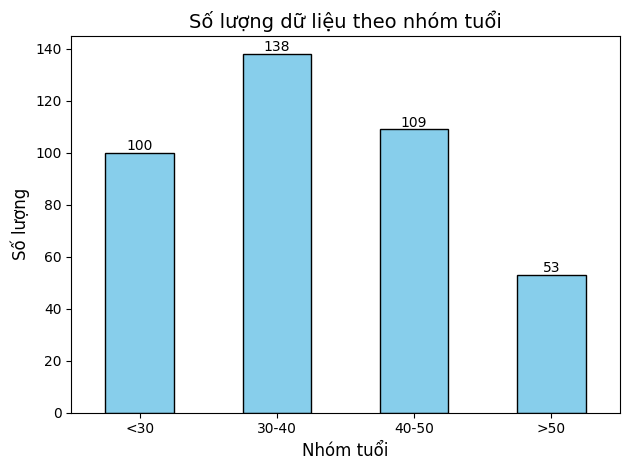

In [ ]:
# Tạo biểu đồ cột
ax = age_group_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(age_group_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo nhóm tuổi', fontsize=14)
plt.xlabel('Nhóm tuổi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

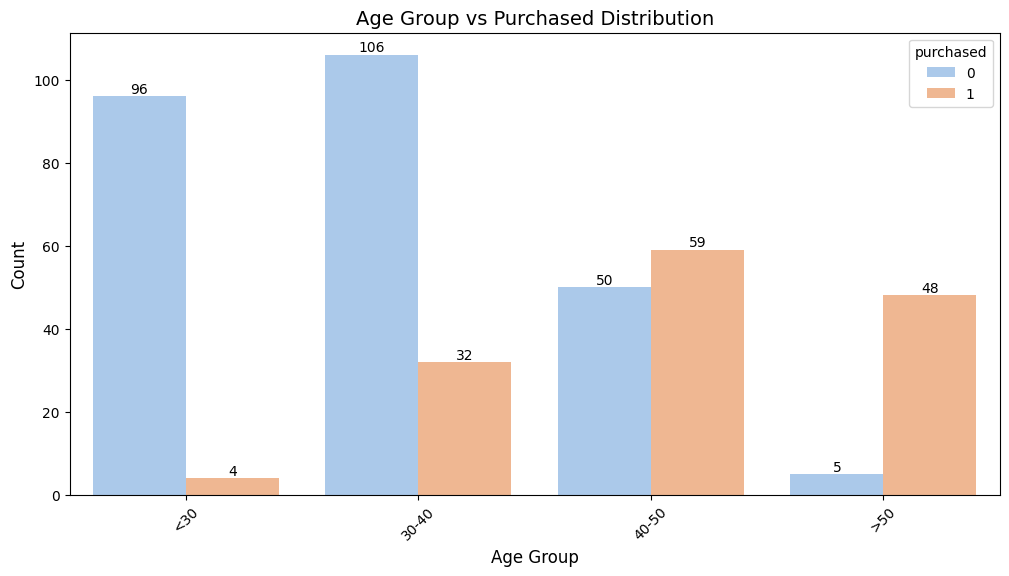

In [ ]:
# Tạo biểu đồ
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='age_group', hue='purchased', palette='pastel')
plt.xticks(rotation=45)
plt.title('Age Group vs Purchased Distribution', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Thêm nhãn số lượng trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

## Các yếu tố có độ liên quan khác
### Kết luận
- Nữ: Tỷ lệ không mua hàng của phụ nữ (62.25%) thấp hơn so với nam giới (66.33%), nhưng tỷ lệ mua hàng của nữ (37.75%) vẫn cao hơn nam (33.67%).
- Nam: Mặc dù nhóm nam có tỷ lệ không mua hàng cao hơn, nhưng nhóm này vẫn có một lượng đáng kể (33.67%) quyết định mua hàng.

=> Tuy tỉ lệ chênh lệch không cao nhưng tỉ lệ mua hàng ở nữ có phần cao hơn

### Chi tiết
1. Nữ:
- Có 127 người không mua hàng, chiếm 62.25% trong nhóm nữ.
- Có 77 người mua hàng, chiếm 37.75% trong nhóm nữ.
2. Nam:
- Có 130 người không mua hàng, chiếm 66.33% trong nhóm nam.
- Có 66 người mua hàng, chiếm 33.67% trong nhóm nam.

In [ ]:
# Thống kê số lượng dữ liệu theo giới tính
gender_counts = df['gender'].value_counts()

# Thống kê số lượng dữ liệu theo giới tính và trạng thái mua hàng
gender_purchased_counts = df.groupby(['gender', 'purchased']).size().unstack(fill_value=0)

# Thống kê tỷ lệ phần trăm cho mỗi nhóm
gender_purchased_percentage = gender_purchased_counts.div(gender_counts, axis=0) * 100

# Hiển thị kết quả
print("Số lượng dữ liệu theo giới tính:")
print(gender_counts)

print("\nSố lượng dữ liệu theo giới tính và trạng thái mua hàng:")
print(gender_purchased_counts)

print("\nTỷ lệ phần trăm mua hàng theo giới tính:")
print(gender_purchased_percentage)

Số lượng dữ liệu theo giới tính:
gender
Female    204
Male      196
Name: count, dtype: int64

Số lượng dữ liệu theo giới tính và trạng thái mua hàng:
purchased    0   1
gender            
Female     127  77
Male       130  66

Tỷ lệ phần trăm mua hàng theo giới tính:
purchased          0          1
gender                         
Female     62.254902  37.745098
Male       66.326531  33.673469


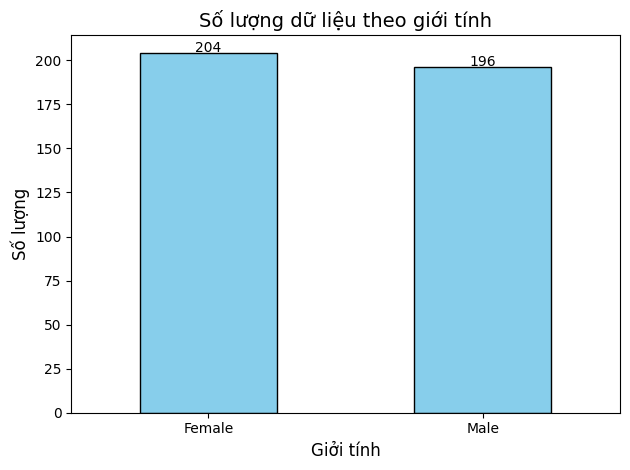

In [ ]:
# Tạo biểu đồ cột
ax = gender_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(gender_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo giới tính', fontsize=14)
plt.xlabel('Giởi tính', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

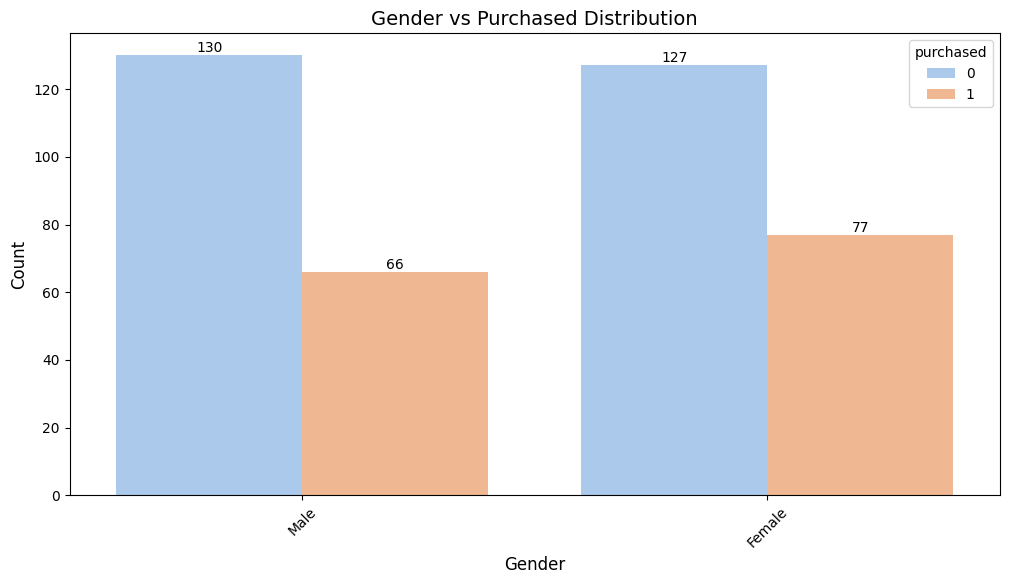

In [ ]:
# Tạo biểu đồ
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='gender', hue='purchased', palette='pastel')
plt.xticks(rotation=45)
plt.title('Gender vs Purchased Distribution', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Thêm nhãn số lượng trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

## Xử lý dữ liệu bị thiếu

In [ ]:
def handling_missing_data(df):
  # Xóa khoảng trắng thừa trong tất cả các chuỗi (nếu có) trước khi thay thế
  df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

  # Thay thế '?' bằng np.nan cho toàn bộ DataFrame
  df.replace('?', np.nan, inplace=True)

  # Kiểm tra lại các giá trị trong tất cả các cột sau khi thay thế
  value_counts_all = {col: df[col].value_counts(dropna=False) for col in df.columns}
  print("Giá trị trong mỗi cột sau khi thay thế '?':")
  print(value_counts_all)

  # Kiểm tra số lượng giá trị thiếu trong toàn bộ DataFrame
  missing_values_count_all = df.isnull().sum()
  print("\nSố lượng giá trị thiếu trong mỗi cột sau khi thay thế '?':")
  print(missing_values_count_all)
  return df

df = handling_missing_data(df)

Giá trị trong mỗi cột sau khi thay thế '?':
{'user_id': user_id
15624510    1
15767681    1
15589449    1
15791373    1
15688172    1
           ..
15675185    1
15792102    1
15722758    1
15745232    1
15594041    1
Name: count, Length: 400, dtype: int64, 'gender': gender
Female    204
Male      196
Name: count, dtype: int64, 'age': age
35    32
37    20
26    16
41    16
42    16
39    15
40    15
48    14
47    14
27    13
38    13
28    12
36    12
46    12
31    11
30    11
49    10
29    10
33     9
32     9
24     9
59     7
19     7
45     7
20     7
60     7
34     6
23     6
52     6
25     6
58     6
53     5
57     5
22     5
18     5
21     4
50     4
54     4
55     3
56     3
51     3
43     3
44     2
Name: count, dtype: int64, 'estimated': estimated
72000     12
80000     11
79000     10
75000      9
71000      9
          ..
123000     1
37000      1
115000     1
148000     1
139000     1
Name: count, Length: 117, dtype: int64, 'purchased': purchased
0    257
1    14

## Chuẩn hóa dữ liệu

In [ ]:
# Biến đổi các cột phân loại thành giá trị
label_encoder = LabelEncoder()

categorical_columns = ['gender', 'age', 'estimated', 'purchased','estimated_category','age_group']


for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
display(df.head())

,user_id,gender,age,estimated,purchased,estimated_category,age_group
1,15624510,1,1,4,0,0,2
2,15810944,1,17,5,0,0,0
3,15668575,0,8,26,0,0,2
4,15603246,0,9,39,0,1,2
5,15804002,1,1,57,0,1,2


In [ ]:
# Chuẩn hóa các biến liên tục
scaler = StandardScaler()
continuous_columns = ['age','estimated']
df[continuous_columns] = scaler.fit_transform(df[continuous_columns])
display(df.head())

,user_id,gender,age,estimated,purchased,estimated_category,age_group
1,15624510,1,-1.781797,-1.550229,0,0,2
2,15810944,1,-0.253587,-1.516623,0,0,0
3,15668575,0,-1.113206,-0.810904,0,0,2
4,15603246,0,-1.017692,-0.374031,0,1,2
5,15804002,1,-1.781797,0.230871,0,1,2


## Biểu diễn độ tương quan của dữ liệu liên tục và phân loại

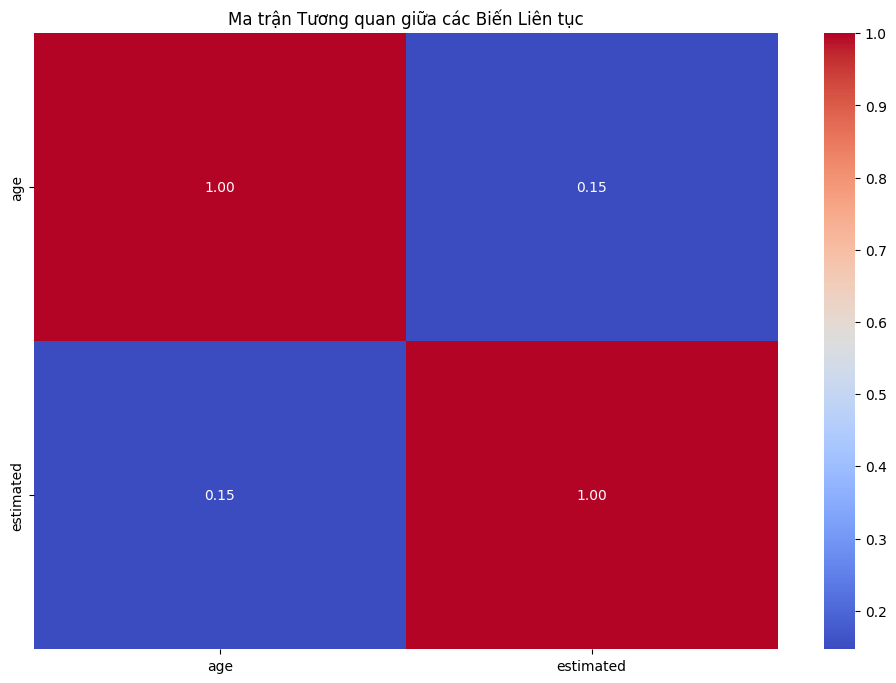

In [ ]:
# Lọc ra các biến liên tục
continuous_features = ['age', 'estimated']
continuous_df = df[continuous_features]

# Tính toán ma trận tương quan
correlation_matrix = continuous_df.corr()

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận Tương quan giữa các Biến Liên tục')
plt.show()

Tính Cramér's V xác định mối quan hệ giữa hai biến phân loại

In [ ]:
# Hàm tính Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

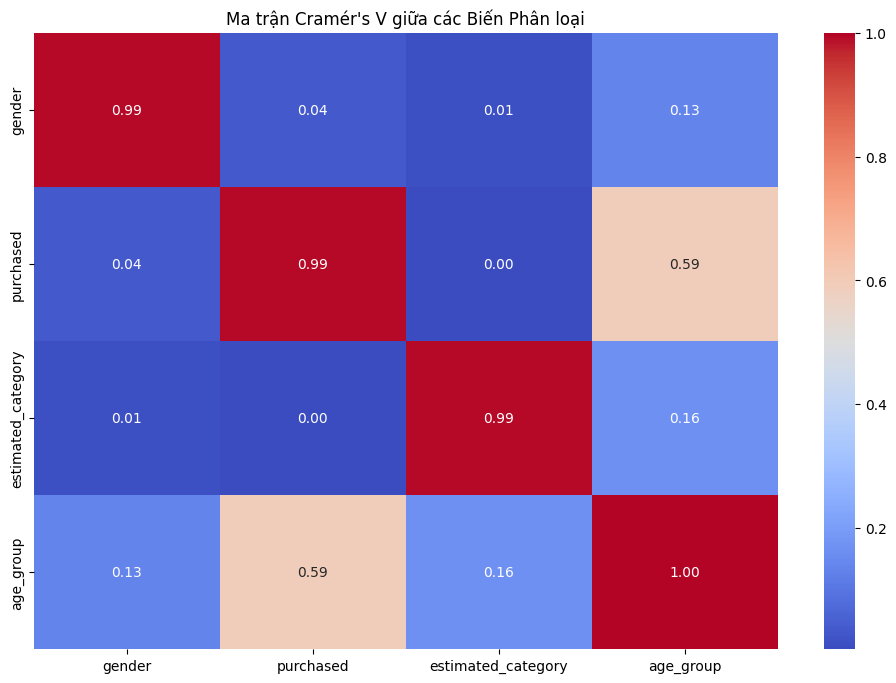

In [ ]:
# Tính Cramér's V cho các biến phân loại

categorical_columns = ['gender', 'purchased', 'estimated_category', 'age_group']

cramers_v_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

for col1 in categorical_columns:
    for col2 in categorical_columns:
        cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Hiển thị ma trận Cramér's V cho các biến phân loại
plt.figure(figsize=(12, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận Cramér's V giữa các Biến Phân loại")
plt.show()

## Loại bỏ các feature nhiễu trong dữ liệu liên tục


In [ ]:
# Thiết lập ngưỡng cho độ tương quan
threshold = 0.7

# Lưu trữ tên các biến cần loại bỏ
to_drop = set()

# Tìm các cặp biến có độ tương quan cao
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:  # So sánh giá trị tuyệt đối
            # Ghi lại tên của biến để loại bỏ
            colname = correlation_matrix.columns[i]  # Tên của biến hiện tại
            to_drop.add(colname)  # Thêm vào danh sách loại bỏ

# In các biến sẽ được loại bỏ
print("Các biến sẽ bị loại bỏ do tương quan cao:", to_drop)

# Lọc bỏ các biến này khỏi DataFrame gốc
filtered_continuous_df = continuous_df.drop(columns=to_drop)

# In kích thước của DataFrame sau khi lọc
print("Kích thước DataFrame sau khi lọc:", filtered_continuous_df.shape)

# Chuyển đổi DataFrame sau khi lọc thành mảng NumPy
filtered_array = filtered_continuous_df

# In mảng đã lọc
print("Mảng dữ liệu sau khi lọc:")
print(filtered_array)

Các biến sẽ bị loại bỏ do tương quan cao: set()
Kích thước DataFrame sau khi lọc: (400, 2)
Mảng dữ liệu sau khi lọc:
          age  estimated
1   -1.781797  -1.550229
2   -0.253587  -1.516623
3   -1.113206  -0.810904
4   -1.017692  -0.374031
5   -1.781797   0.230871
..        ...        ...
396  0.797057  -0.878116
397  1.274623  -1.415806
398  1.179110  -1.516623
399 -0.158074  -1.113355
400  1.083596  -1.012538

[400 rows x 2 columns]


In [ ]:
# Lọc ra các biến phân loại có tương quan cao
filtered_categorical_df = df[categorical_columns]

# Kết hợp DataFrame liên tục đã lọc và phân loại đã lọc
final_filtered_df = pd.concat([filtered_continuous_df.reset_index(drop=True), filtered_categorical_df.reset_index(drop=True)], axis=1)

# In kích thước của DataFrame sau khi kết hợp
print("Kích thước DataFrame cuối cùng sau khi kết hợp:", final_filtered_df.shape)

# In DataFrame đã kết hợp
print("DataFrame đã lọc và kết hợp:")
display(final_filtered_df.head())  # Hiển thị 5 dòng đầu tiên

Kích thước DataFrame cuối cùng sau khi kết hợp: (400, 6)
DataFrame đã lọc và kết hợp:


,age,estimated,gender,purchased,estimated_category,age_group
0,-1.781797,-1.550229,1,0,0,2
1,-0.253587,-1.516623,1,0,0,0
2,-1.113206,-0.810904,0,0,0,2
3,-1.017692,-0.374031,0,0,1,2
4,-1.781797,0.230871,1,0,1,2



## Biểu diễn Data sau khi tiền xử lý





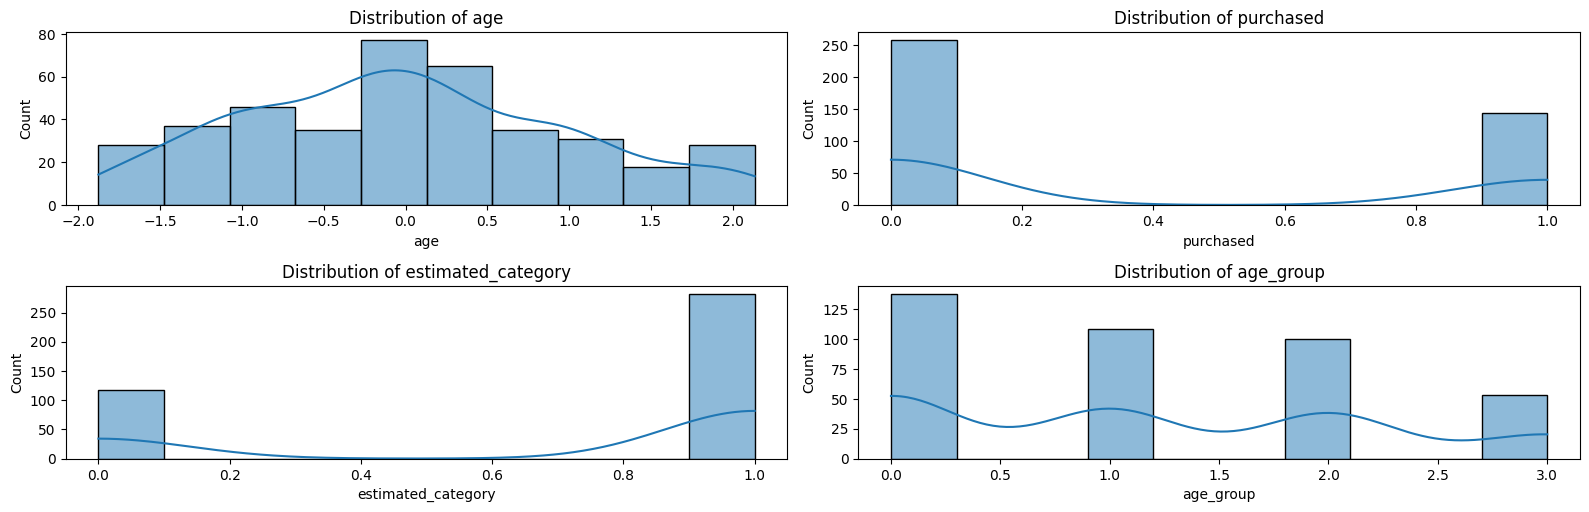

In [ ]:
columns_to_plot = ['age', 'purchased', 'estimated_category', 'age_group']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(16, 20))

# Lặp qua từng cột để vẽ biểu đồ phân bố
for i, column in enumerate(columns_to_plot):
    plt.subplot(8, 2, i + 1)  # Sắp xếp biểu đồ trong 8 hàng và 2 cột
    if final_filtered_df[column].dtype in ['int64', 'float64']:
        # Nếu cột là số, vẽ biểu đồ histogram
        sns.histplot(final_filtered_df[column], kde=True)
        plt.title(f'Distribution of {column}')
    else:
        # Nếu cột là phân loại, vẽ biểu đồ bar
        sns.countplot(data=final_filtered_df, x=column, order=final_filtered_df[column].value_counts().index)
        plt.title(f'Distribution of {column}')

# Tinh chỉnh bố cục cho đẹp
plt.tight_layout()
plt.show()

## Mất cân bằng dữ liệu. Dùng oversampling

Số lượng mẫu cho từng lớp:
purchased
0    257
1    143
Name: count, dtype: int64


<ipython-input-64-1f16cf8785c9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


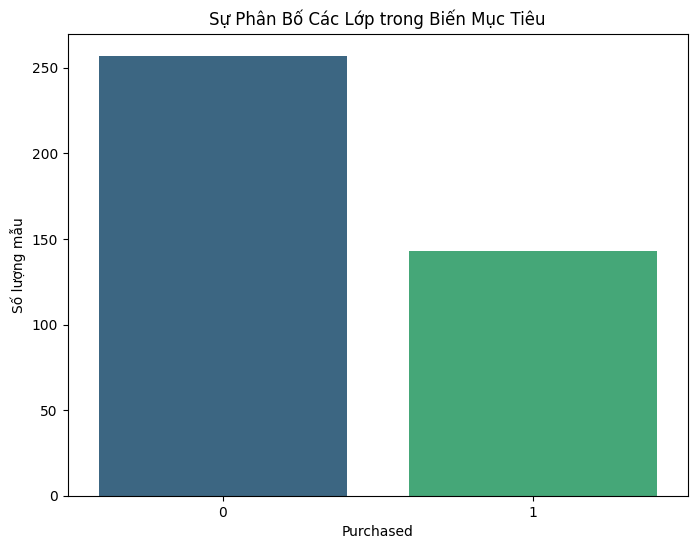

In [ ]:
# Giả sử bạn đã có DataFrame tên là final_filtered_df với biến mục tiêu là 'income'
# Kiểm tra số lượng mẫu cho từng lớp
class_counts = final_filtered_df['purchased'].value_counts()

# In số lượng mẫu cho từng lớp
print("Số lượng mẫu cho từng lớp:")
print(class_counts)

# Vẽ biểu đồ phân bố
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Sự Phân Bố Các Lớp trong Biến Mục Tiêu')
plt.xlabel('Purchased')
plt.ylabel('Số lượng mẫu')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Tạo đối tượng SMOTE
smote = SMOTE(random_state=42)

# Tách dữ liệu thành features và target
X = final_filtered_df.drop(columns=['purchased'])
y = final_filtered_df['purchased']

# Áp dụng SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Kiểm tra số lượng mẫu sau khi Oversampling
print("Số lượng mẫu sau khi Oversampling:")
print(y_resampled.value_counts())

Số lượng mẫu sau khi Oversampling:
purchased
0    257
1    257
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
# Tạo DataFrame mới từ các biến đã được oversample
oversampled_df = pd.DataFrame(X_resampled, columns=X.columns)
oversampled_df['purchased'] = y_resampled

# Hiển thị 5 dòng đầu tiên của DataFrame mới
print("Dataset sau khi Oversampling:")
print(oversampled_df.head())

# Kiểm tra kích thước của dataset sau khi Oversampling
print("Kích thước của dataset sau khi Oversampling:", oversampled_df.shape)

Dataset sau khi Oversampling:
        age  estimated  gender  estimated_category  age_group  purchased
0 -1.781797  -1.550229       1                   0          2          0
1 -0.253587  -1.516623       1                   0          0          0
2 -1.113206  -0.810904       0                   0          2          0
3 -1.017692  -0.374031       0                   1          2          0
4 -1.781797   0.230871       1                   1          2          0
Kích thước của dataset sau khi Oversampling: (514, 6)


## Xáo trộn dữ liệu trước khi train

In [ ]:
# Xáo trộn dữ liệu trong DataFrame
oversampled_df_shuffled = oversampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Hiển thị 5 dòng đầu tiên của DataFrame đã xáo trộn
print("Dataset sau khi xáo trộn:")
print(oversampled_df_shuffled.head())

# Kiểm tra kích thước của dataset sau khi xáo trộn
print("Kích thước của dataset sau khi xáo trộn:", oversampled_df_shuffled.shape)

Dataset sau khi xáo trộn:
        age  estimated  gender  estimated_category  age_group  purchased
0  0.223978  -0.273214       0                   1          1          0
1 -0.391771   1.112472       0                   1          0          1
2  0.293944   0.095665       1                   1          1          1
3 -0.158074  -0.575665       0                   1          0          0
4  0.923546  -1.214172       0                   0          1          1
Kích thước của dataset sau khi xáo trộn: (514, 6)


## Train Model

In [ ]:
X = oversampled_df_shuffled.drop(columns=['purchased'])
y = oversampled_df_shuffled['purchased']

## Dùng phương pháp tách OneHotEncoder để model dễ học hơn

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Xác định các biến liên tục và phân loại
continuous_features = ['age']
categorical_features = ['estimated_category', 'age_group', 'gender' ]

# Tách dữ liệu liên tục và phân loại
X_continuous = X[continuous_features]
X_categorical = X[categorical_features]

# Áp dụng OneHotEncoder cho các biến phân loại
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_categorical_encoded = encoder.fit_transform(X_categorical)

# Kết hợp dữ liệu liên tục và dữ liệu đã mã hóa
X_encoded = pd.DataFrame(X_categorical_encoded, index=X.index)  # Sử dụng chỉ số từ X để giữ nguyên hàng
X_encoded = pd.concat([X_continuous.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

# Chuyển đổi tất cả tên cột thành kiểu str
X_encoded.columns = X_encoded.columns.astype(str)

In [ ]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.4, random_state=42)

# Kiểm tra kích thước của các tập dữ liệu
print("Kích thước của tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước của tập kiểm tra:", X_test.shape, y_test.shape)

Kích thước của tập huấn luyện: (308, 6) (308,)
Kích thước của tập kiểm tra: (206, 6) (206,)


## Tạo Mô hình Gaussian Naive Bayes và 3 mô hình khác: Decision Tree, Logistic Regression, KNN

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Tạo từ điển lưu trữ các mô hình
model_results = {
    'GaussianNB': {'model': GaussianNB(), 'accuracy': None},
    'DecisionTree': {'model': DecisionTreeClassifier(), 'accuracy': None},
    'LogisticRegression': {'model': LogisticRegression(max_iter=1000), 'accuracy': None},
    'KNeighbors': {'model': KNeighborsClassifier(), 'accuracy': None}
}

Độ chính xác của mô hình GaussianNB: 0.77


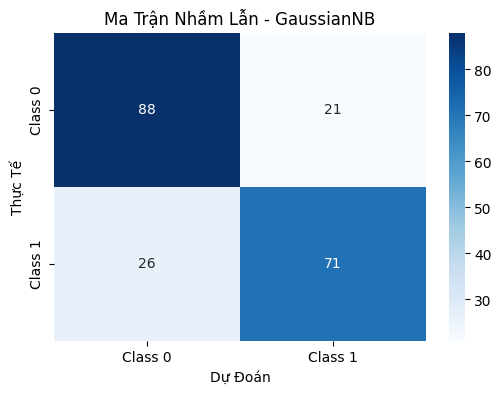

Độ chính xác của mô hình DecisionTree: 0.80


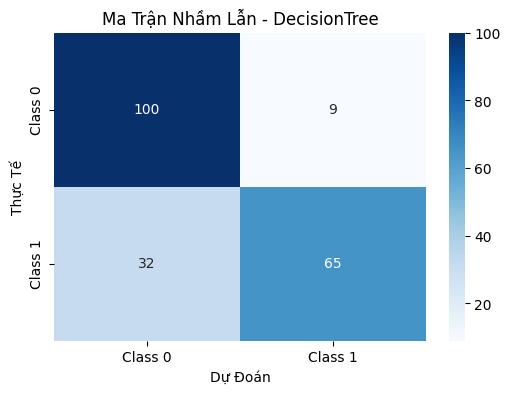

Độ chính xác của mô hình LogisticRegression: 0.79


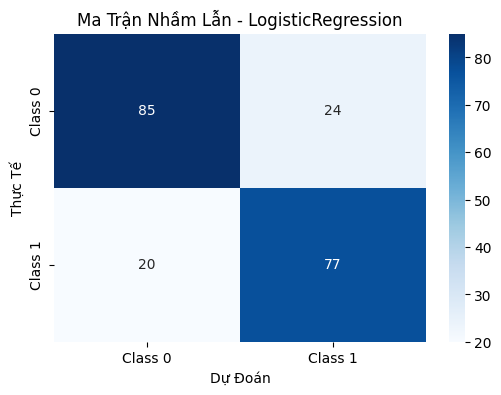

Độ chính xác của mô hình KNeighbors: 0.78


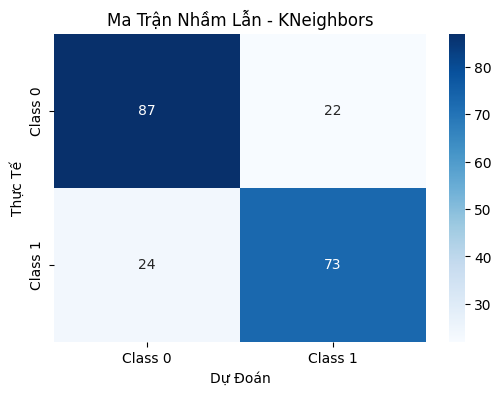

In [ ]:
# Huấn luyện các mô hình
for model_name, results in model_results.items():
    results['model'].fit(X_train, y_train)  # Huấn luyện mô hình

# Tính toán độ chính xác và các thông số khác
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Lặp qua từng mô hình và lấy thông số
for model_name, results in model_results.items():
    # Dự đoán trên dữ liệu kiểm tra
    y_pred = results['model'].predict(X_test)

    # Tính toán báo cáo phân loại
    report = classification_report(y_test, y_pred, output_dict=True)

    # Lưu trữ các thông số
    accuracy = accuracy_score(y_test, y_pred)  # Tính toán độ chính xác
    results['accuracy'] = accuracy  # Lưu trữ độ chính xác
    accuracy_scores.append(accuracy)  # Lưu trữ độ chính xác
    precision_scores.append(report['1']['precision'])  # Lưu trữ độ chính xác
    recall_scores.append(report['1']['recall'])  # Lưu trữ độ nhạy
    f1_scores.append(report['1']['f1-score'])  # Lưu trữ điểm F1

    # In ra độ chính xác
    print(f"Độ chính xác của mô hình {model_name}: {accuracy:.2f}")

    # In ma trận nhầm lẫn
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Ma Trận Nhầm Lẫn - {model_name}')
    plt.xlabel('Dự Đoán')
    plt.ylabel('Thực Tế')
    plt.show()

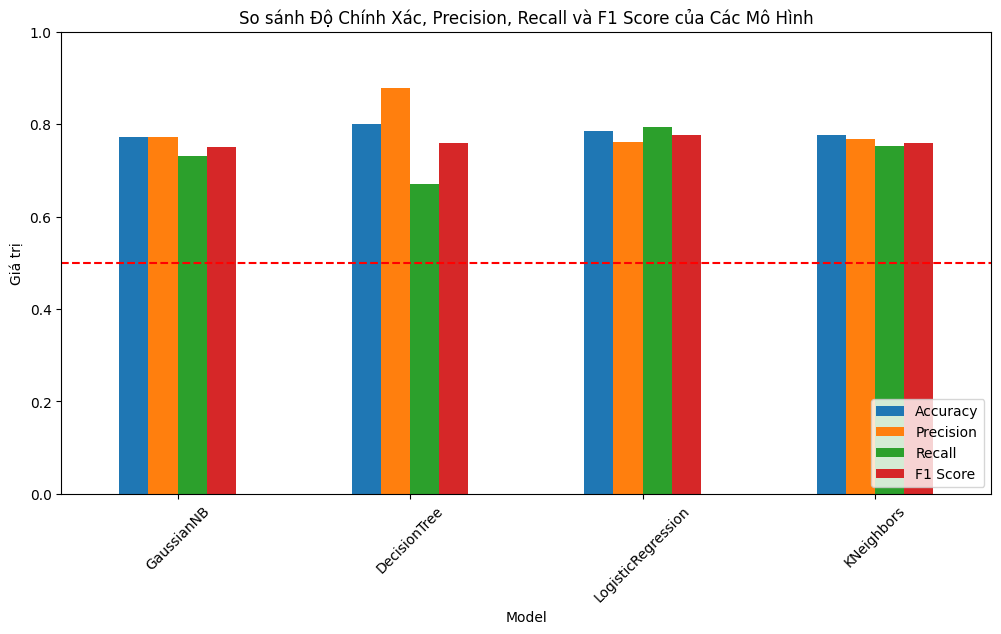

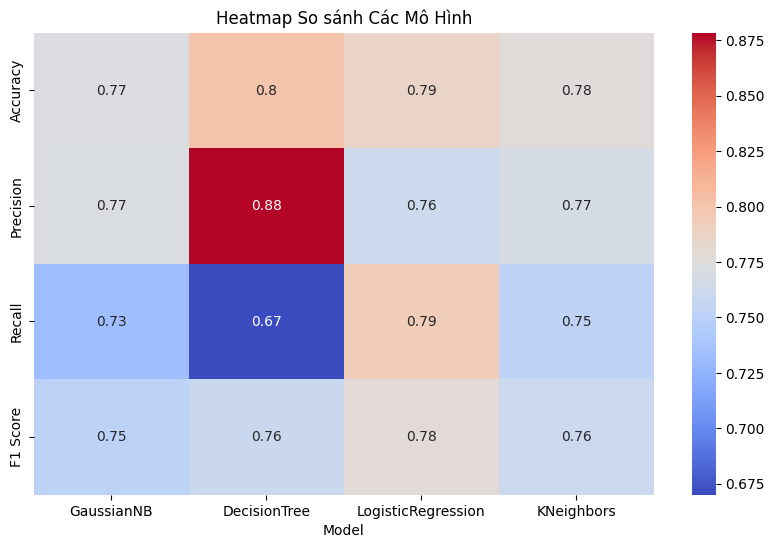

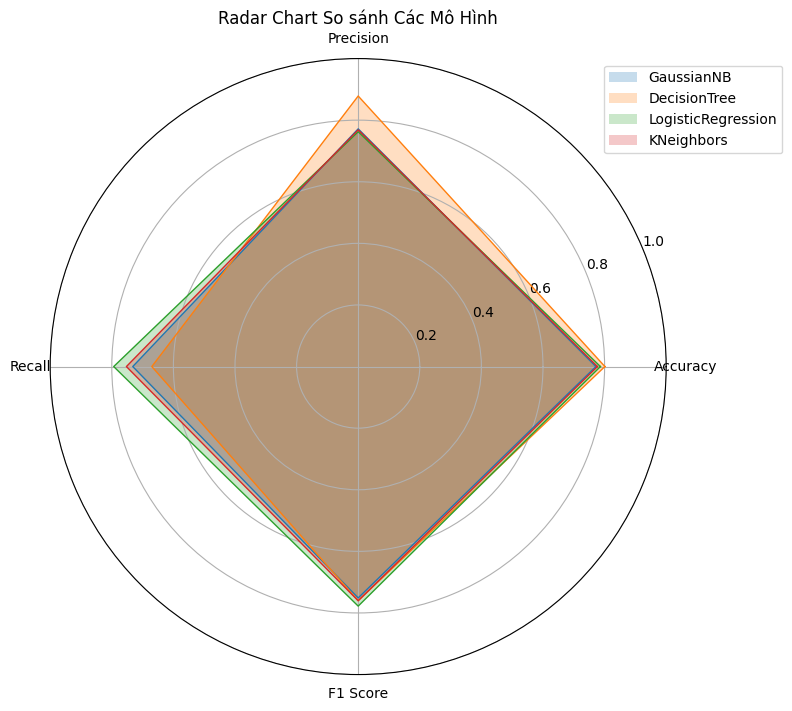

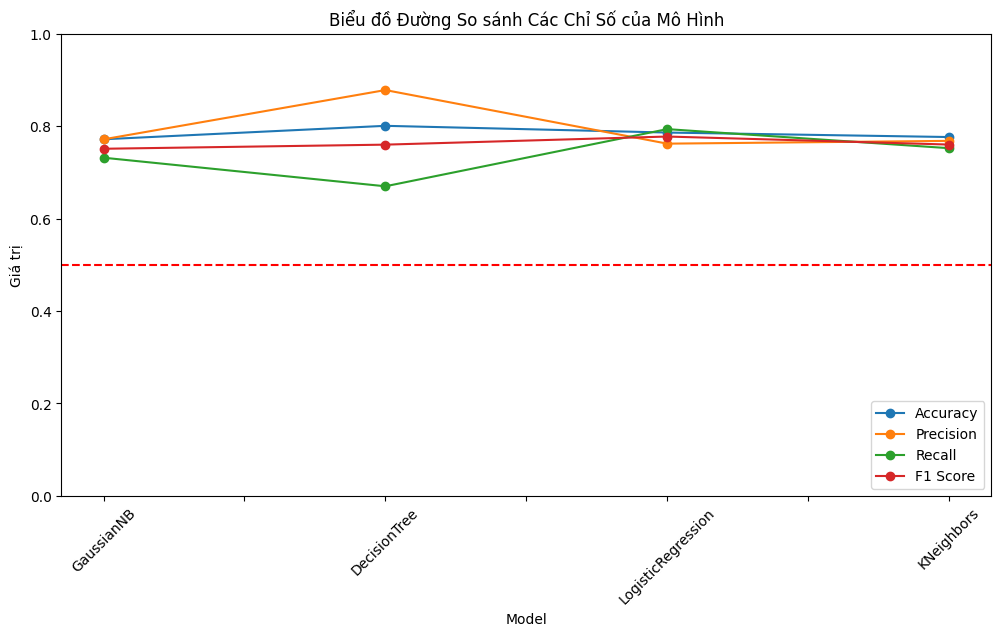

In [ ]:
# Tạo DataFrame từ kết quả chứa các chỉ số cho từng mô hình
metrics_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

# 1. Bar Plot - Biểu đồ cột
metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('So sánh Độ Chính Xác, Precision, Recall và F1 Score của Các Mô Hình')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linestyle='--')
plt.legend(loc='lower right')
plt.show()

# 2. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.set_index('Model').T, annot=True, cmap='coolwarm', cbar=True)
plt.title('Heatmap So sánh Các Mô Hình')
plt.show()

# 3. Radar Chart
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Đóng vòng tròn

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, model in enumerate(metrics_df['Model']):
    values = metrics_df.loc[i, labels].tolist()
    values += values[:1]
    ax.fill(angles, values, alpha=0.25, label=model)
    ax.plot(angles, values, linewidth=1)

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Radar Chart So sánh Các Mô Hình')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# 4. Line Plot
metrics_df.set_index('Model').plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Biểu đồ Đường So sánh Các Chỉ Số của Mô Hình')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linestyle='--')
plt.legend(loc='lower right')
plt.show()

# Dùng model học được dự đoán khả năng mua hàng trong tập Adult


In [ ]:
file_path = '/content/adult.csv'
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df = pd.read_csv(file_path,header=None, names=col_names)

# Hiển thị 5 dòng đầu
print(df.head())

# Thông tin cấu trúc của dữ liệu
df.info()

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [ ]:
df['gender'] = df['sex']
df['estimated_category'] = df['income']
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Male,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Male,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Male,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Male,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Female,<=50K


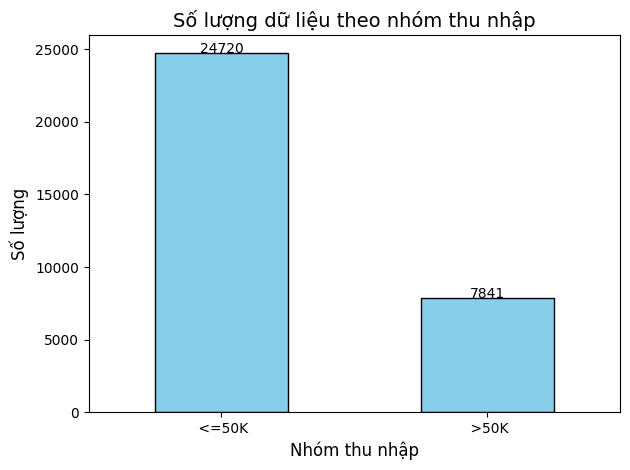

In [ ]:
import matplotlib.pyplot as plt

# Đảm bảo cột 'estimated_category' được sắp xếp theo thứ tự xác định
# tmpdf['estimated_category'] = pd.Categorical(
#     tmpdf['estimated_category'],
#     categories=['<=50k', '>50k'],
#     ordered=True
# )

# Đếm số lượng dữ liệu trong từng nhóm
category_counts = df['estimated_category'].value_counts(sort=False)

# Tạo biểu đồ cột
ax = category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(category_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo nhóm thu nhập', fontsize=14)
plt.xlabel('Nhóm thu nhập', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Chuyển đổi cột 'age' thành kiểu số (numeric) trước khi phân loại
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Định nghĩa lại các khoảng giá trị và nhãn
age_bins = [0, 30, 40, 50, float('inf')]  # Dùng float('inf') để đại diện cho giá trị lớn hơn 50
age_labels = ['<30', '30-40', '40-50', '>50']

# Phân loại nhóm tuổi
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Đảm bảo cột được sắp xếp theo thứ tự tuổi
df['age_group'] = pd.Categorical(df['age_group'], categories=age_labels, ordered=True)

# Đếm số lượng dữ liệu trong từng nhóm tuổi
age_group_counts = df['age_group'].value_counts(sort=False)

# Hiển thị kết quả
print("Số lượng dữ liệu trong từng nhóm tuổi:")
print(age_group_counts)

new_df = df   #copy


display(df.head())

Số lượng dữ liệu trong từng nhóm tuổi:
age_group
<30      9711
30-40    8613
40-50    7175
>50      7062
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Male,<=50K,30-40
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Male,<=50K,>50
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Male,<=50K,30-40
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Male,<=50K,>50
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Female,<=50K,<30


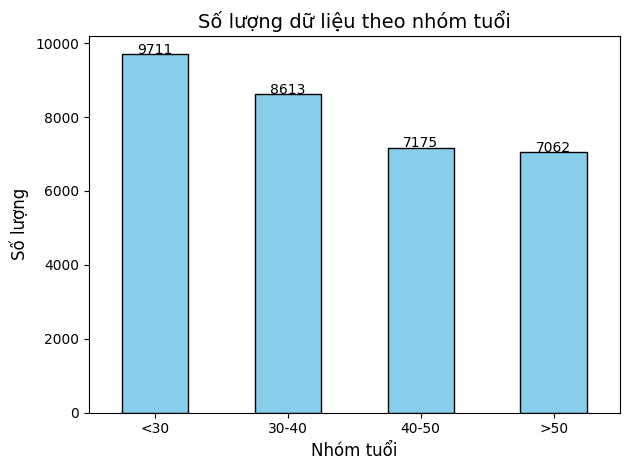

In [ ]:
# Tạo biểu đồ cột
ax = age_group_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(age_group_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo nhóm tuổi', fontsize=14)
plt.xlabel('Nhóm tuổi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chuẩn hóa dữ liệu trước khi dự đoán khả năng mua hàng

In [ ]:
# Xóa khoảng trắng thừa trong tất cả các chuỗi (nếu có) trước khi thay thế
df = handling_missing_data(df)
display(df.head())

Giá trị trong mỗi cột sau khi thay thế '?':
{'age': age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64, 'workclass': workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64, 'fnlwgt': fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
232784     1
325573     1
140176     1
318264     1
257302     1
Name: count, Length: 21648, dtype: int64, 'education': education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Male,<=50K,30-40
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Male,<=50K,>50
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Male,<=50K,30-40
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Male,<=50K,>50
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Female,<=50K,<30


In [ ]:
# Biến đổi các cột phân loại thành giá trị
label_encoder = LabelEncoder()

categorical_columns = ['age', 'gender', 'estimated_category','age_group']


for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group
0,22,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,1,0,0
1,33,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,1,0,3
2,21,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,1,0,0
3,36,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,1,0,3
4,11,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,2


In [ ]:
# Chuẩn hóa các biến liên tục
scaler = StandardScaler()
continuous_columns = ['age']
df[continuous_columns] = scaler.fit_transform(df[continuous_columns])
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group
0,0.030778,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,1,0,0
1,0.837509,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,1,0,3
2,-0.042561,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,1,0,0
3,1.057526,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,1,0,3
4,-0.775952,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,2


## Dự đoán khả năng mua hàng

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Select the features you used for training:
# Assuming 'continuous_features' and 'categorical_features' are defined as in your previous code
prediction_data = df[['age','gender', 'estimated_category', 'age_group']]

# 2. Apply OneHotEncoder to categorical features:
# Assuming 'encoder' is the OneHotEncoder object you fitted during training
categorical_encoded = encoder.transform(prediction_data[categorical_features])
categorical_encoded_df = pd.DataFrame(categorical_encoded, index=prediction_data.index)
categorical_encoded_df.columns = categorical_encoded_df.columns.astype(str)

# 3. Scale continuous features:
# Assuming 'scaler' is the StandardScaler object you fitted during training
continuous_scaled = scaler.transform(prediction_data[continuous_features])
continuous_scaled_df = pd.DataFrame(continuous_scaled, index=prediction_data.index, columns=continuous_features)

# 4. Combine the preprocessed data:
preprocessed_prediction_data = pd.concat([continuous_scaled_df, categorical_encoded_df], axis=1)

# 5. Make predictions using the preprocessed data:
df['purchase'] = model_results['GaussianNB']['model'].predict(preprocessed_prediction_data)
new_df['purchase'] = df['purchase']


In [ ]:
display(df.head(10))
display(new_df.head(10))

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group,purchase
0,0.030778,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,1,0,0,0
1,0.837509,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,1,0,3,1
2,-0.042561,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,1,0,0,0
3,1.057526,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,1,0,3,1
4,-0.775952,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,2,0
5,-0.115900,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,0,0,0,0
6,0.764169,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K,0,0,1,0
7,0.984187,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K,1,1,3,1
8,-0.555934,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K,0,1,0,0
9,0.250796,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K,1,1,1,0


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group,purchase
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Male,<=50K,30-40,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Male,<=50K,>50,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Male,<=50K,30-40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Male,<=50K,>50,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Female,<=50K,<30,0
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,Female,<=50K,30-40,0
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K,Female,<=50K,40-50,0
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K,Male,>50K,>50,1
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K,Female,>50K,30-40,0
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K,Male,>50K,40-50,0


Số lượng mẫu cho từng lớp:
purchase
0    25499
1     7062
Name: count, dtype: int64


<ipython-input-87-6a77a9369754>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


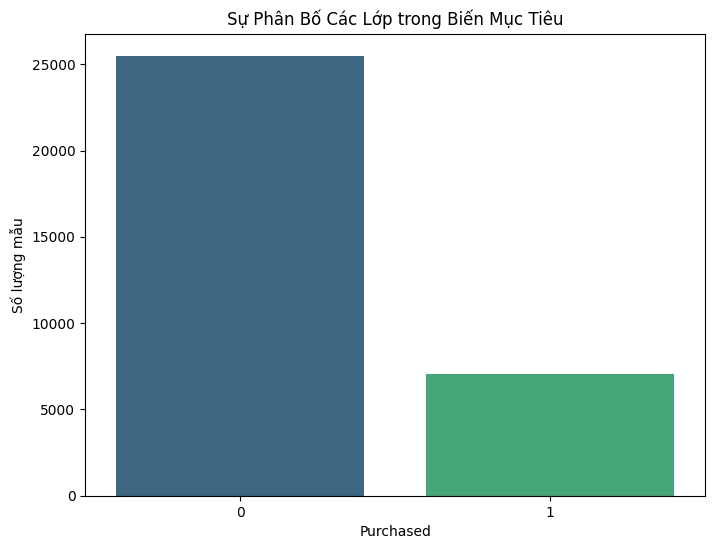

In [ ]:
# Giả sử bạn đã có DataFrame tên là final_filtered_df với biến mục tiêu là 'income'
# Kiểm tra số lượng mẫu cho từng lớp
class_counts = new_df['purchase'].value_counts()

# In số lượng mẫu cho từng lớp
print("Số lượng mẫu cho từng lớp:")
print(class_counts)

# Vẽ biểu đồ phân bố
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Sự Phân Bố Các Lớp trong Biến Mục Tiêu')
plt.xlabel('Purchased')
plt.ylabel('Số lượng mẫu')
plt.show()

In [ ]:
new_df.to_csv('new_adult.csv', index=False)


# Tạo model mới từ tập new_adult

In [ ]:
# Danh sách tên cột (header)
file_path = '/content/new_adult.csv'
# col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
#              'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income','gender', 'estimated_category'	'age_group'	'purchase']

df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu
print(df.head())

# Thông tin cấu trúc của dữ liệu
df.info()

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  \
0          2174             0              40   United-States   <=5

In [ ]:
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,gender,estimated_category,age_group,purchase
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Male,<=50K,30-40,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Male,<=50K,>50,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Male,<=50K,30-40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Male,<=50K,>50,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Female,<=50K,<30,0


In [ ]:
df = df.drop(columns=['sex', 'income'])
display(df.head())


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,gender,estimated_category,age_group,purchase
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,Male,<=50K,30-40,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,Male,<=50K,>50,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,Male,<=50K,30-40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,Male,<=50K,>50,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,Female,<=50K,<30,0


## So sánh độ tương quan của Estimated Category so với Purchased

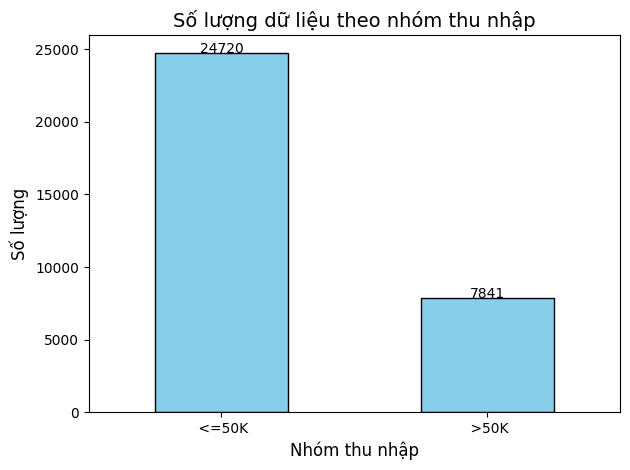

In [ ]:
import matplotlib.pyplot as plt


# Đếm số lượng dữ liệu trong từng nhóm
category_counts = df['estimated_category'].value_counts(sort=False)

# Tạo biểu đồ cột
ax = category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm số lượng trên đầu cột
for i, count in enumerate(category_counts):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

# Thiết lập tiêu đề và nhãn
plt.title('Số lượng dữ liệu theo nhóm thu nhập', fontsize=14)
plt.xlabel('Nhóm thu nhập', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Đảm bảo cột 'estimated_category' được sắp xếp theo thứ tự xác định

# Thống kê số lượng mỗi nhóm `estimated_category` theo `purchased`
summary = df.groupby(['estimated_category', 'purchase'], observed=False).size().unstack(fill_value=0)

print("Thống kê số lượng mỗi nhóm theo purchase:")
print(summary)

# Tính tỷ lệ phần trăm cho từng nhóm
summary_percentage = (summary.T / summary.sum(axis=1) * 100).T

print("\nTỷ lệ phần trăm mỗi nhóm theo purchase:")
print(summary_percentage)

Thống kê số lượng mỗi nhóm theo purchase:
purchase                0     1
estimated_category             
<=50K               20017  4703
>50K                 5482  2359

Tỷ lệ phần trăm mỗi nhóm theo purchase:
purchase                    0          1
estimated_category                      
<=50K               80.974919  19.025081
>50K                69.914552  30.085448


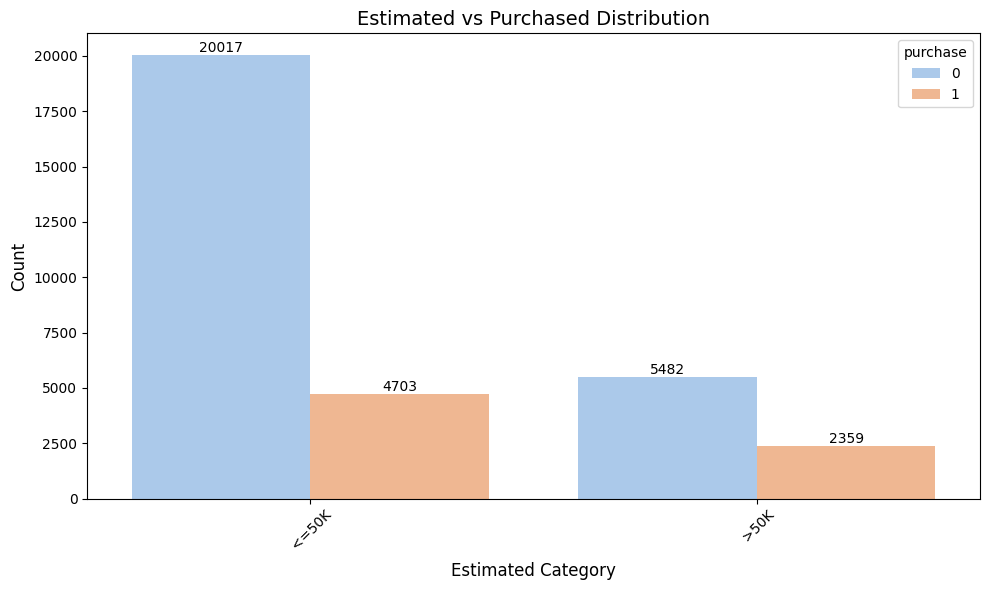

In [ ]:
# Tạo biểu đồ
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='estimated_category', hue='purchase', palette='pastel')
plt.xticks(rotation=45)
plt.title('Estimated vs Purchased Distribution', fontsize=14)
plt.xlabel('Estimated Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Thêm số lượng trên mỗi cột
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## So sánh độ tương quan của Workclass so với Purchased

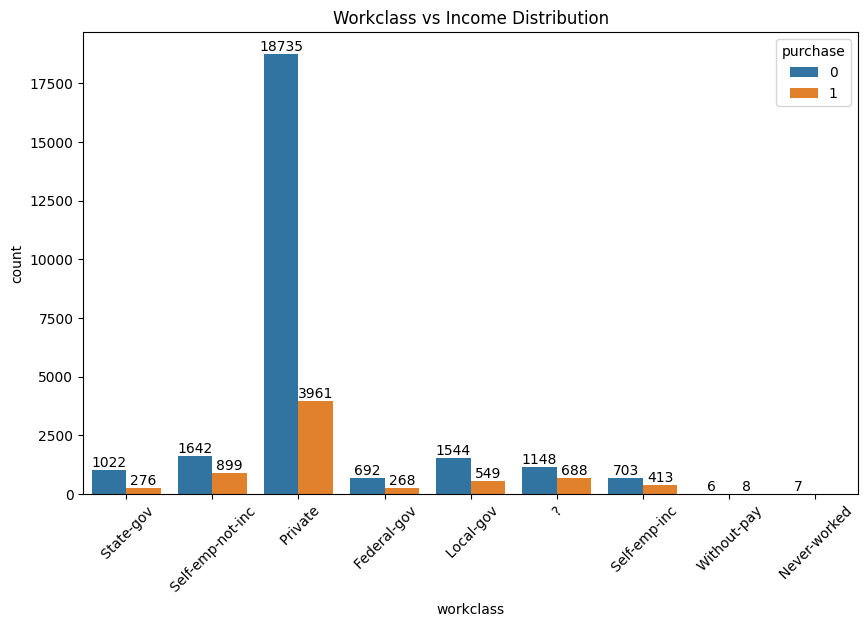

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df,x='workclass',hue='purchase')
plt.xticks(rotation=45)
plt.title('Workclass vs Income Distribution')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## So sánh độ tương quan của Occupation so với Purchased

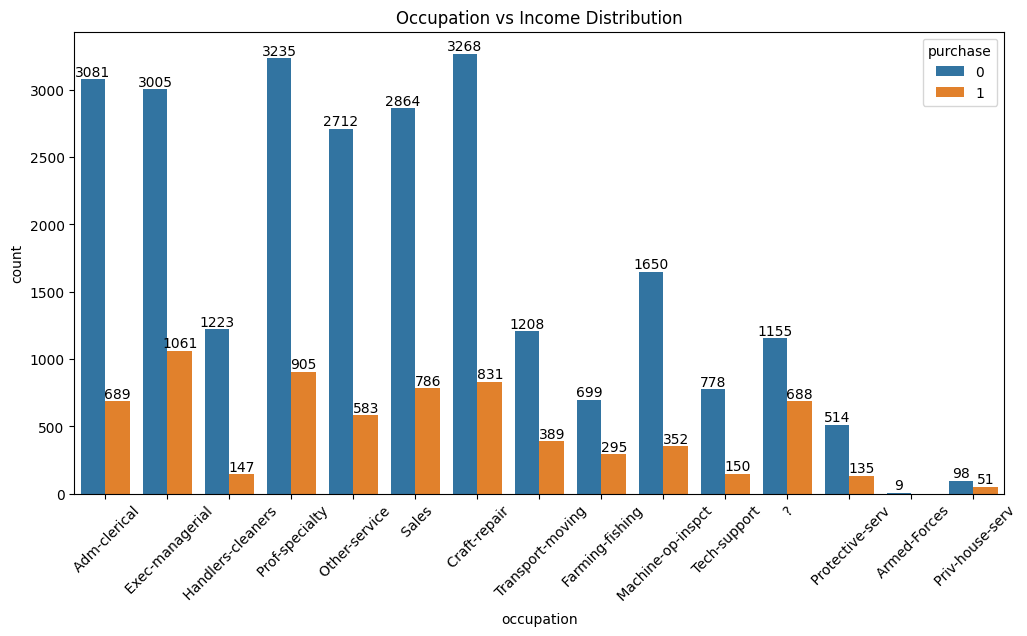

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df,x='occupation',hue='purchase')
plt.xticks(rotation=45)
plt.title('Occupation vs Income Distribution')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## Các yếu tố có độ liên quan khác

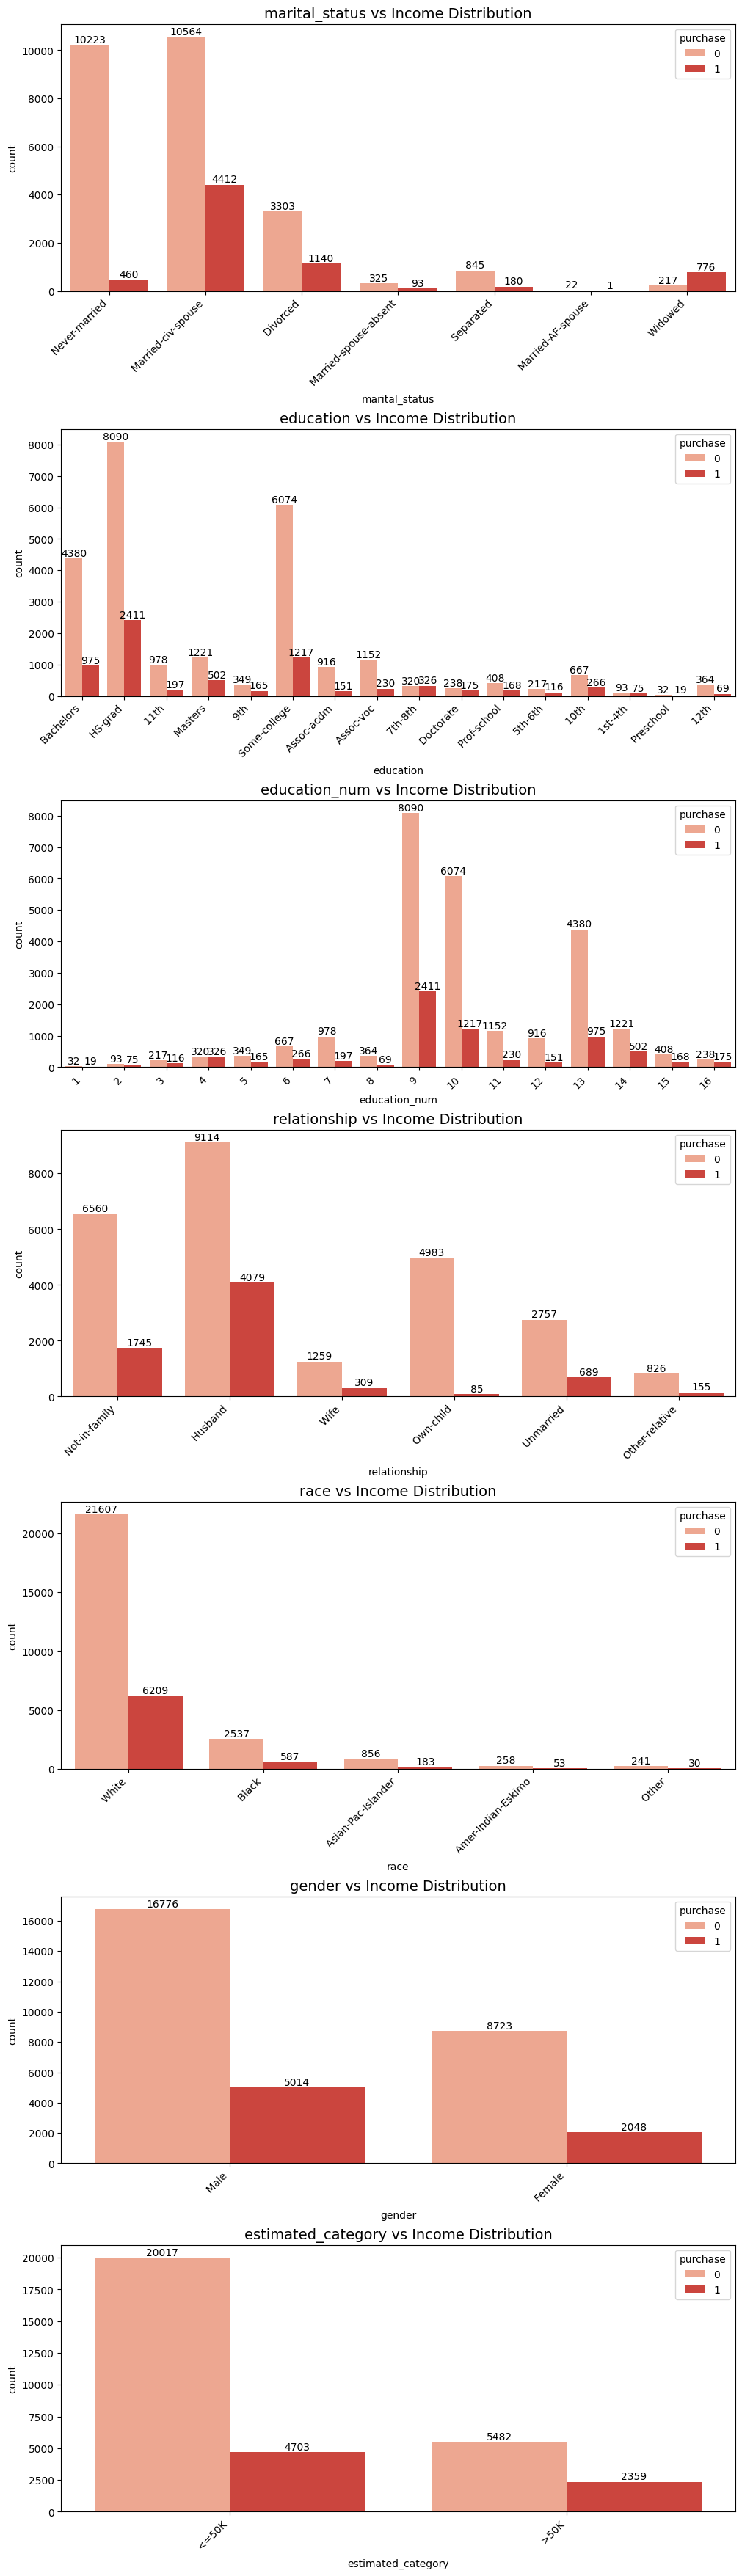

In [ ]:
small_range_cols = ['marital_status','education','education_num','relationship','race','gender', 'estimated_category']

nRows = len(small_range_cols)
fig, ax = plt.subplots(nRows, 1, figsize=(10, 5 * nRows), constrained_layout=True)


for i, col in enumerate(small_range_cols):
    sns.countplot(data=df, x=col, hue='purchase', palette='Reds', ax=ax[i])


    for container in ax[i].containers:
        ax[i].bar_label(container)


    ax[i].set_title(f"{col} vs Income Distribution", fontsize=14)
    plt.setp(ax[i].get_xticklabels(), rotation=45, ha='right')


plt.show()

## Xữ lí dữ liệu bị thiếu

In [ ]:
df = handling_missing_data(df)

Giá trị trong mỗi cột sau khi thay thế '?':
{'age': age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64, 'workclass': workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64, 'fnlwgt': fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
232784     1
325573     1
140176     1
318264     1
257302     1
Name: count, Length: 21648, dtype: int64, 'education': education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413


In [ ]:
# Điền giá trị thiếu cho các biến phân loại bằng giá trị phổ biến nhất (mode)
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['native_country'] = df['native_country'].fillna(df['native_country'].mode()[0])

# Kiểm tra lại số lượng giá trị thiếu
print(df.isnull().sum())

age                   0
workclass             0
fnlwgt                0
education             0
education_num         0
marital_status        0
occupation            0
relationship          0
race                  0
capital_gain          0
capital_loss          0
hours_per_week        0
native_country        0
gender                0
estimated_category    0
age_group             0
purchase              0
dtype: int64


## Chuẩn hóa dữ liệu

In [ ]:
# Biến đổi các cột phân loại thành giá trị
label_encoder = LabelEncoder()

categorical_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country','gender', 'estimated_category', 'purchase']


for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,gender,estimated_category,age_group,purchase
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,1,0,30-40,0
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,1,0,>50,1
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,1,0,30-40,0
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,1,0,>50,1
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,0,0,<30,0


In [ ]:
# Chuẩn hóa các biến liên tục
scaler = StandardScaler()
continuous_columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
df[continuous_columns] = scaler.fit_transform(df[continuous_columns])
display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,gender,estimated_category,age_group,purchase
0,0.030671,6,-1.063611,9,1.134739,4,0,1,4,0.148453,-0.21666,-0.035429,38,1,0,30-40,0
1,0.837109,5,-1.008707,9,1.134739,2,3,0,4,-0.145920,-0.21666,-2.222153,38,1,0,>50,1
2,-0.042642,3,0.245079,11,-0.420060,0,5,1,4,-0.145920,-0.21666,-0.035429,38,1,0,30-40,0
3,1.057047,3,0.425801,1,-1.197459,2,5,0,2,-0.145920,-0.21666,-0.035429,38,1,0,>50,1
4,-0.775768,3,1.408176,9,1.134739,2,9,5,2,-0.145920,-0.21666,-0.035429,4,0,0,<30,0


## Biểu diễn độ tương quan của dữ liệu liên tục và phân loại

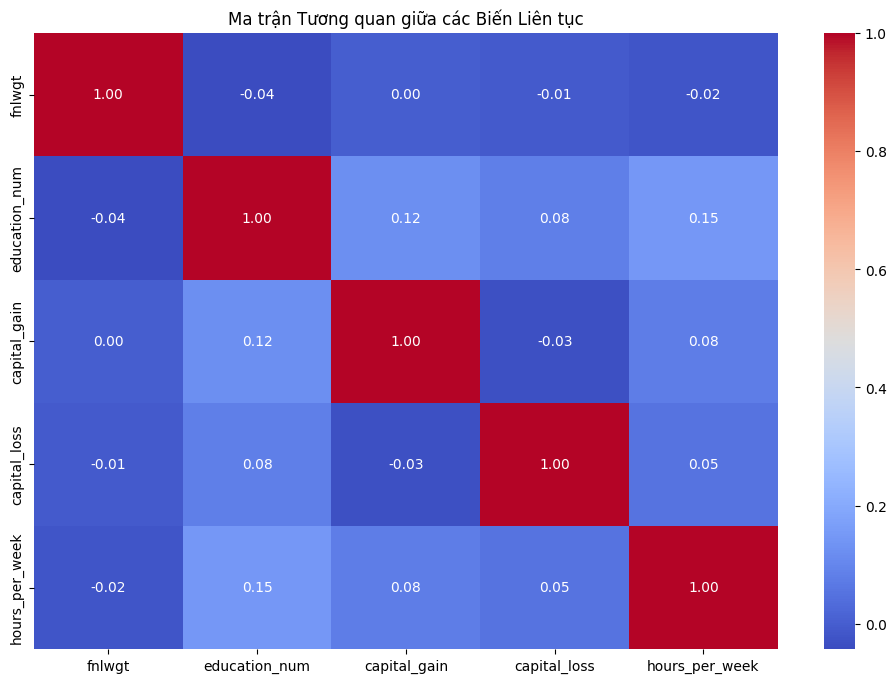

In [ ]:
# Lọc ra các biến liên tục
continuous_features = ['fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
continuous_df = df[continuous_features]

# Tính toán ma trận tương quan
correlation_matrix = continuous_df.corr()

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận Tương quan giữa các Biến Liên tục')
plt.show()

Tính Cramér's V xác định mối quan hệ giữa hai biến phân loại

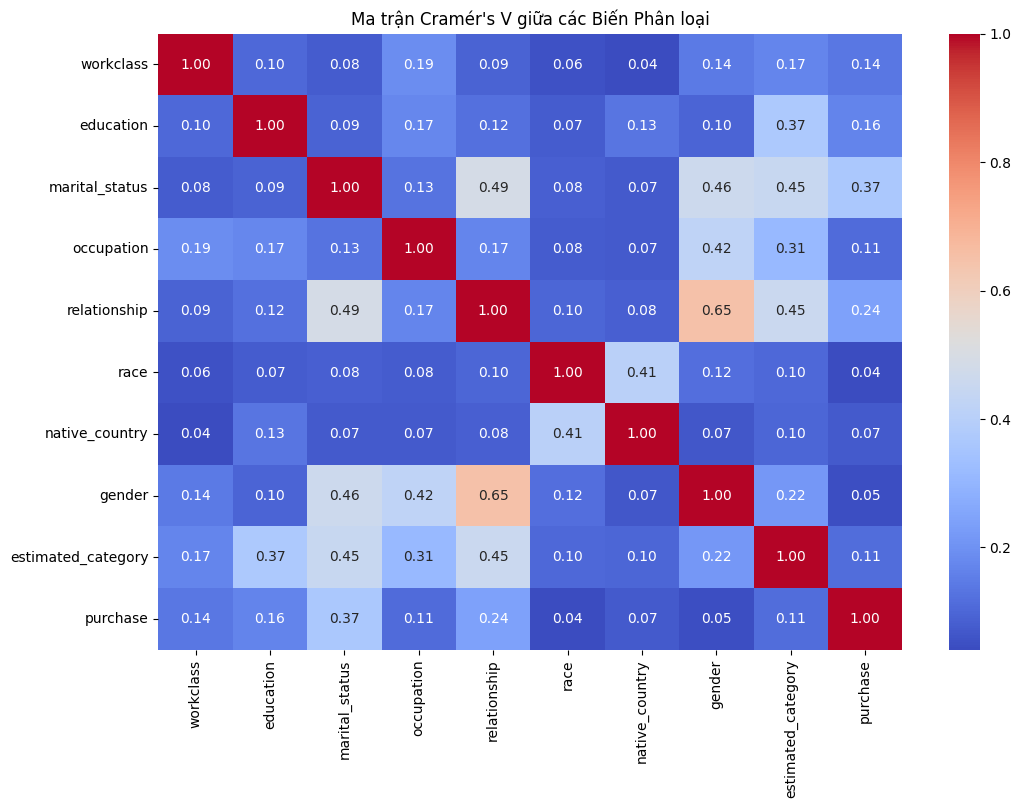

In [ ]:
# Tính Cramér's V cho các biến phân loại
categorical_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country','gender', 'estimated_category', 'purchase']
cramers_v_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

for col1 in categorical_columns:
    for col2 in categorical_columns:
        cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Hiển thị ma trận Cramér's V cho các biến phân loại
plt.figure(figsize=(12, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận Cramér's V giữa các Biến Phân loại")
plt.show()

## Loại bỏ các feature nhiễu trong dữ liệu liên tục

In [ ]:
# Thiết lập ngưỡng cho độ tương quan
threshold = 0.7

# Lưu trữ tên các biến cần loại bỏ
to_drop = set()

# Tìm các cặp biến có độ tương quan cao
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:  # So sánh giá trị tuyệt đối
            # Ghi lại tên của biến để loại bỏ
            colname = correlation_matrix.columns[i]  # Tên của biến hiện tại
            to_drop.add(colname)  # Thêm vào danh sách loại bỏ

# In các biến sẽ được loại bỏ
print("Các biến sẽ bị loại bỏ do tương quan cao:", to_drop)

# Lọc bỏ các biến này khỏi DataFrame gốc
filtered_continuous_df = continuous_df.drop(columns=to_drop)

# In kích thước của DataFrame sau khi lọc
print("Kích thước DataFrame sau khi lọc:", filtered_continuous_df.shape)

# Chuyển đổi DataFrame sau khi lọc thành mảng NumPy
filtered_array = filtered_continuous_df

# In mảng đã lọc
print("Mảng dữ liệu sau khi lọc:")
print(filtered_array)

Các biến sẽ bị loại bỏ do tương quan cao: set()
Kích thước DataFrame sau khi lọc: (32561, 5)
Mảng dữ liệu sau khi lọc:
         fnlwgt  education_num  capital_gain  capital_loss  hours_per_week
0     -1.063611       1.134739      0.148453      -0.21666       -0.035429
1     -1.008707       1.134739     -0.145920      -0.21666       -2.222153
2      0.245079      -0.420060     -0.145920      -0.21666       -0.035429
3      0.425801      -1.197459     -0.145920      -0.21666       -0.035429
4      1.408176       1.134739     -0.145920      -0.21666       -0.035429
...         ...            ...           ...           ...             ...
32556  0.639741       0.746039     -0.145920      -0.21666       -0.197409
32557 -0.335433      -0.420060     -0.145920      -0.21666       -0.035429
32558 -0.358777      -0.420060     -0.145920      -0.21666       -0.035429
32559  0.110960      -0.420060     -0.145920      -0.21666       -1.655225
32560  0.929893      -0.420060      1.888424      -0.216

## Sử dụng cramers để tính toán và loại bỏ dữ liệu nhiễu của data phân loại

In [ ]:
# Giả sử cramers_v_matrix đã được tính toán
cramer_v_income = cramers_v_matrix['purchase'].astype(float)
high_cramer_v_features = cramer_v_income[cramer_v_income > 0.1].index.tolist()  # Ngưỡng 0.2
low_cramer_v_features = cramer_v_income[cramer_v_income <= 0.1].index.tolist()
print("Biến phân loại có tương quan cao với income:", high_cramer_v_features)
print("Biến phân loại có tương quan thấp với income:", low_cramer_v_features)


Biến phân loại có tương quan cao với income: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'estimated_category', 'purchase']
Biến phân loại có tương quan thấp với income: ['race', 'native_country', 'gender']


In [ ]:
# Lọc ra các biến phân loại có tương quan cao
filtered_categorical_df = df[high_cramer_v_features]

# Kết hợp DataFrame liên tục đã lọc và phân loại đã lọc
final_filtered_df = pd.concat([filtered_continuous_df.reset_index(drop=True), filtered_categorical_df.reset_index(drop=True)], axis=1)

# In kích thước của DataFrame sau khi kết hợp
print("Kích thước DataFrame cuối cùng sau khi kết hợp:", final_filtered_df.shape)

# In DataFrame đã kết hợp
print("DataFrame đã lọc và kết hợp:")
display(final_filtered_df.head())  # Hiển thị 5 dòng đầu tiên

Kích thước DataFrame cuối cùng sau khi kết hợp: (32561, 12)
DataFrame đã lọc và kết hợp:


,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass,education,marital_status,occupation,relationship,estimated_category,purchase
0,-1.063611,1.134739,0.148453,-0.21666,-0.035429,6,9,4,0,1,0,0
1,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,5,9,2,3,0,0,1
2,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,3,11,0,5,1,0,0
3,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,3,1,2,5,0,0,1
4,1.408176,1.134739,-0.145920,-0.21666,-0.035429,3,9,2,9,5,0,0


## Biểu diễn Data sau khi tiền xử lý

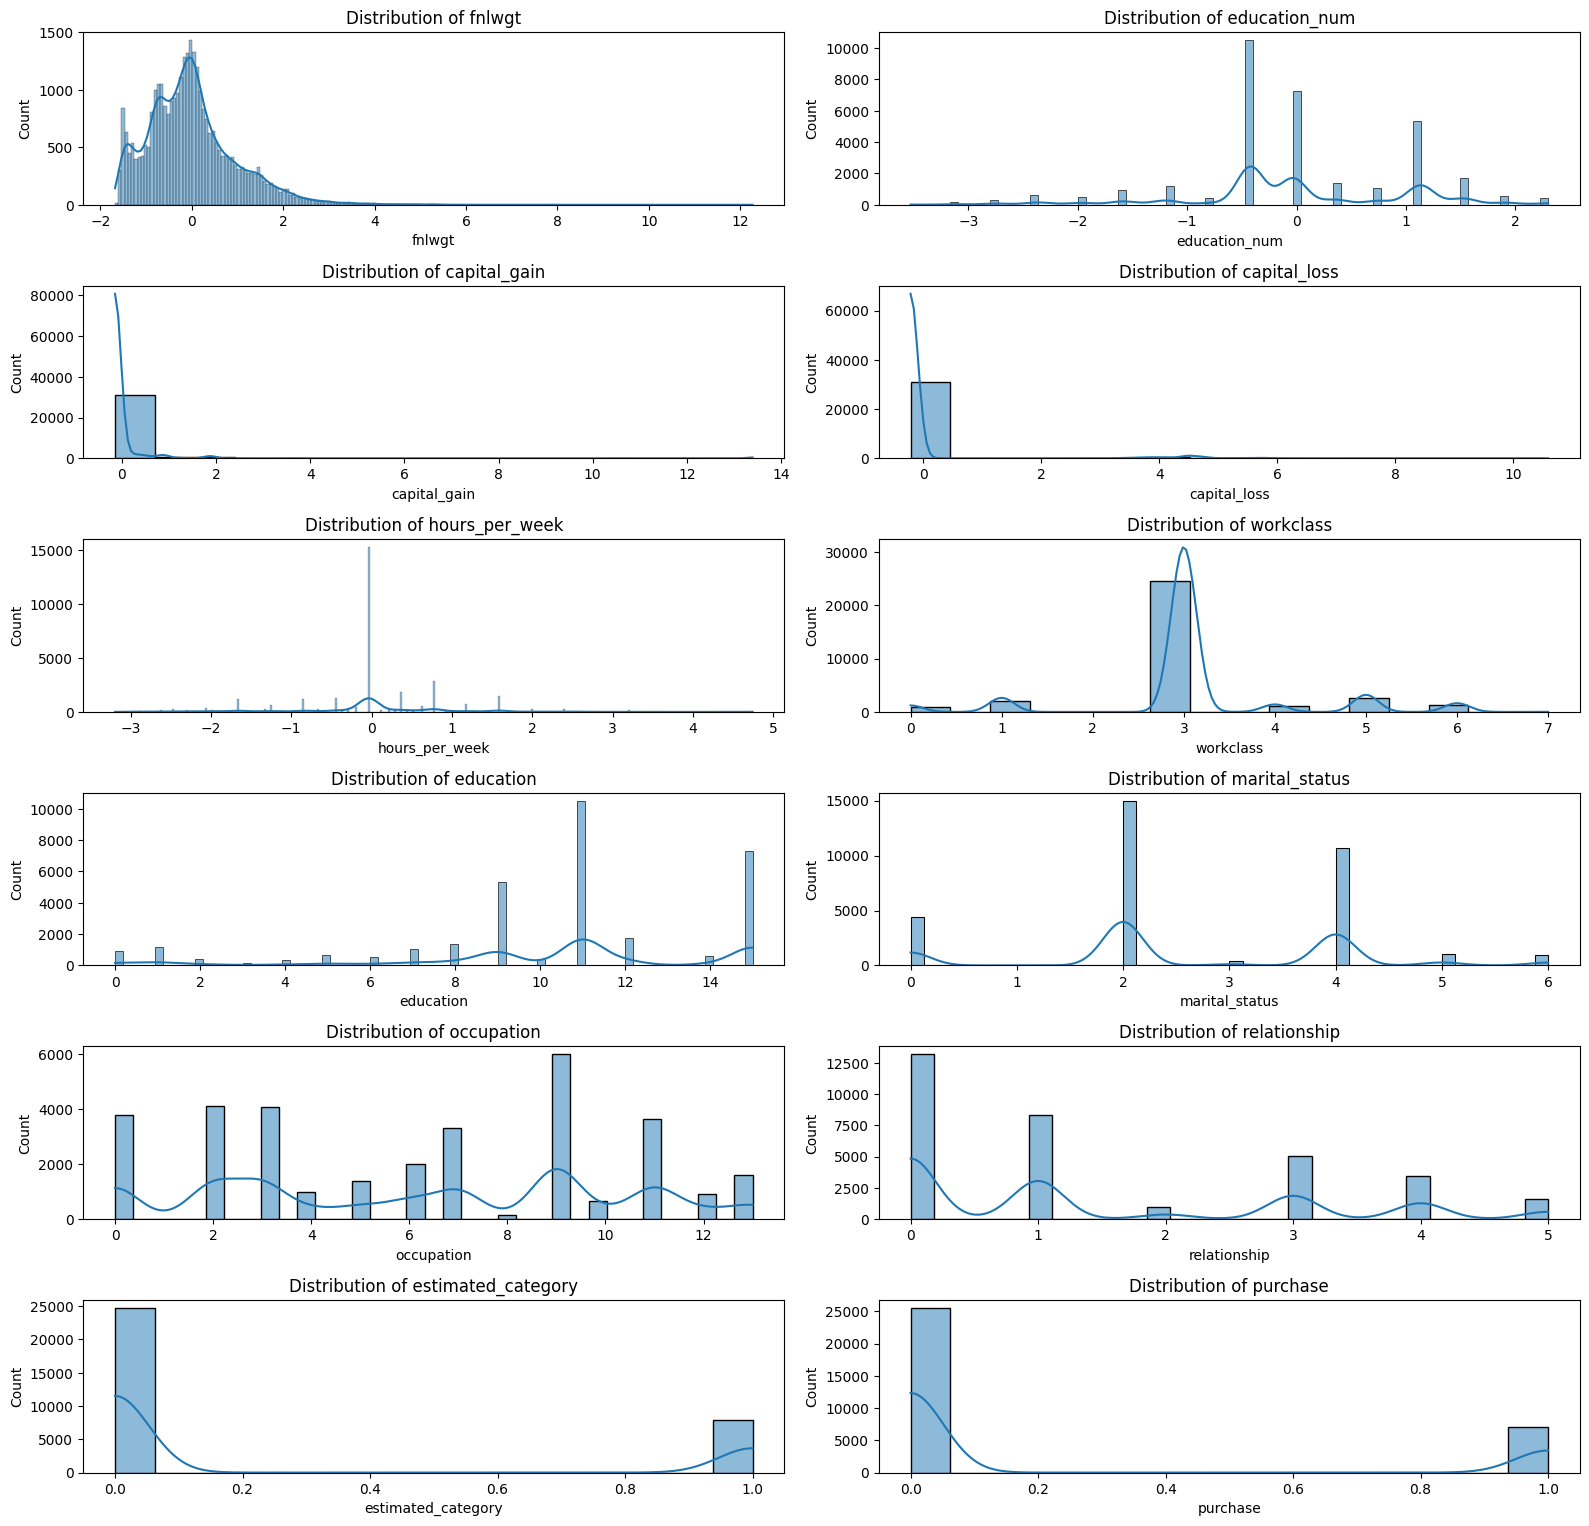

In [ ]:
columns_to_plot = ['fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
                   'hours_per_week', 'workclass', 'education', 'marital_status',
                   'occupation', 'relationship', 'estimated_category', 'purchase']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(16, 20))

# Lặp qua từng cột để vẽ biểu đồ phân bố
for i, column in enumerate(columns_to_plot):
    plt.subplot(8, 2, i + 1)  # Sắp xếp biểu đồ trong 8 hàng và 2 cột
    if final_filtered_df[column].dtype in ['int64', 'float64']:
        # Nếu cột là số, vẽ biểu đồ histogram
        sns.histplot(final_filtered_df[column], kde=True)
        plt.title(f'Distribution of {column}')
    else:
        # Nếu cột là phân loại, vẽ biểu đồ bar
        sns.countplot(data=final_filtered_df, x=column, order=final_filtered_df[column].value_counts().index)
        plt.title(f'Distribution of {column}')

# Tinh chỉnh bố cục cho đẹp
plt.tight_layout()
plt.show()

## Mất cân bằng dữ liệu. Dùng oversampling

Số lượng mẫu cho từng lớp:
purchase
0    25499
1     7062
Name: count, dtype: int64


<ipython-input-108-3f51a1b28e4a>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


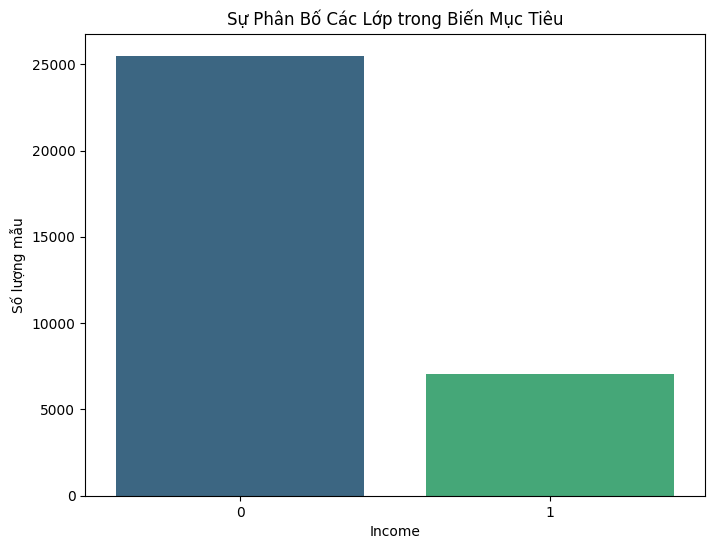

In [ ]:
# Giả sử bạn đã có DataFrame tên là final_filtered_df với biến mục tiêu là 'income'
# Kiểm tra số lượng mẫu cho từng lớp
class_counts = final_filtered_df['purchase'].value_counts()

# In số lượng mẫu cho từng lớp
print("Số lượng mẫu cho từng lớp:")
print(class_counts)

# Vẽ biểu đồ phân bố
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Sự Phân Bố Các Lớp trong Biến Mục Tiêu')
plt.xlabel('Income')
plt.ylabel('Số lượng mẫu')
plt.show()

In [ ]:
# Tạo đối tượng SMOTE
smote = SMOTE(random_state=42)

# Tách dữ liệu thành features và target
X = final_filtered_df.drop(columns=['purchase'])
y = final_filtered_df['purchase']

# Áp dụng SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Kiểm tra số lượng mẫu sau khi Oversampling
print("Số lượng mẫu sau khi Oversampling:")
print(y_resampled.value_counts())

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Số lượng mẫu sau khi Oversampling:
purchase
0    25499
1    25499
Name: count, dtype: int64


In [ ]:
# Tạo DataFrame mới từ các biến đã được oversample
oversampled_df = pd.DataFrame(X_resampled, columns=X.columns)
oversampled_df['purchase'] = y_resampled

# Hiển thị 5 dòng đầu tiên của DataFrame mới
print("Dataset sau khi Oversampling:")
print(oversampled_df.head())

# Kiểm tra kích thước của dataset sau khi Oversampling
print("Kích thước của dataset sau khi Oversampling:", oversampled_df.shape)


Dataset sau khi Oversampling:
     fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0 -1.063611       1.134739      0.148453      -0.21666       -0.035429   
1 -1.008707       1.134739     -0.145920      -0.21666       -2.222153   
2  0.245079      -0.420060     -0.145920      -0.21666       -0.035429   
3  0.425801      -1.197459     -0.145920      -0.21666       -0.035429   
4  1.408176       1.134739     -0.145920      -0.21666       -0.035429   

   workclass  education  marital_status  occupation  relationship  \
0          6          9               4           0             1   
1          5          9               2           3             0   
2          3         11               0           5             1   
3          3          1               2           5             0   
4          3          9               2           9             5   

   estimated_category  purchase  
0                   0         0  
1                   0         1  
2       

## Xáo trộn dữ liệu trước khi train

In [ ]:
# Xáo trộn dữ liệu trong DataFrame
oversampled_df_shuffled = oversampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Hiển thị 5 dòng đầu tiên của DataFrame đã xáo trộn
print("Dataset sau khi xáo trộn:")
print(oversampled_df_shuffled.head())

# Kiểm tra kích thước của dataset sau khi xáo trộn
print("Kích thước của dataset sau khi xáo trộn:", oversampled_df_shuffled.shape)

Dataset sau khi xáo trộn:
     fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0  1.244810       1.134739      -0.14592      -0.21666       -2.870071   
1 -0.541414      -1.197459      -0.14592      -0.21666       -1.250276   
2 -0.645862      -0.420060      -0.14592      -0.21666       -0.035429   
3 -0.544313      -0.031360      -0.14592      -0.21666       -0.845327   
4 -0.981876      -0.420060      -0.14592      -0.21666       -0.035429   

   workclass  education  marital_status  occupation  relationship  \
0          3          9               0          11             1   
1          3          1               0           8             4   
2          3         11               6           2             4   
3          3         15               3          11             4   
4          6         11               4          10             2   

   estimated_category  purchase  
0                   0         1  
1                   0         0  
2           

## Train Model

In [ ]:
X = oversampled_df_shuffled.drop(columns=['purchase'])
y = oversampled_df_shuffled['purchase']

## Dùng phương pháp tách OneHotEncoder để model dễ học hơn

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Xác định các biến liên tục và phân loại
continuous_features = ['fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'estimated_category']

# Tách dữ liệu liên tục và phân loại
X_continuous = X[continuous_features]
X_categorical = X[categorical_features]

# Áp dụng OneHotEncoder cho các biến phân loại
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_categorical_encoded = encoder.fit_transform(X_categorical)

# Kết hợp dữ liệu liên tục và dữ liệu đã mã hóa
X_encoded = pd.DataFrame(X_categorical_encoded, index=X.index)  # Sử dụng chỉ số từ X để giữ nguyên hàng
X_encoded = pd.concat([X_continuous.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

# Chuyển đổi tất cả tên cột thành kiểu str
X_encoded.columns = X_encoded.columns.astype(str)

In [ ]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.4, random_state=42)

# Kiểm tra kích thước của các tập dữ liệu
print("Kích thước của tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước của tập kiểm tra:", X_test.shape, y_test.shape)


Kích thước của tập huấn luyện: (30598, 52) (30598,)
Kích thước của tập kiểm tra: (20400, 52) (20400,)


## Tạo Mô hình Gaussian Naive Bayes và 3 mô hình khác: Decision Tree, Logistic Regression, KNN

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Khởi tạo các mô hình
models = {
    'GaussianNB': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNeighbors': KNeighborsClassifier()
}

Báo cáo phân loại cho mô hình: GaussianNB
              precision    recall  f1-score       support
0              0.576620  0.891552  0.700309  10180.000000
1              0.763090  0.347945  0.477957  10220.000000
accuracy       0.619216  0.619216  0.619216      0.619216
macro avg      0.669855  0.619749  0.589133  20400.000000
weighted avg   0.670038  0.619216  0.588915  20400.000000




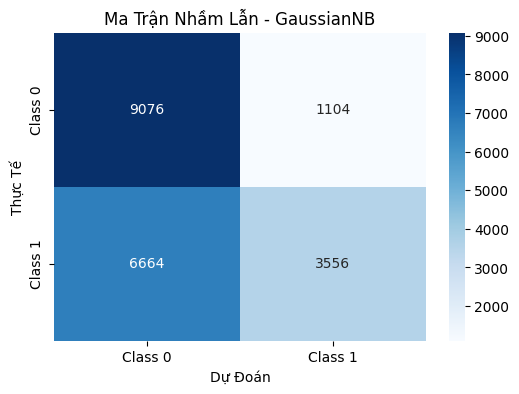

Báo cáo phân loại cho mô hình: DecisionTree
              precision    recall  f1-score       support
0              0.765270  0.751965  0.758559  10180.000000
1              0.757141  0.770254  0.763642  10220.000000
accuracy       0.761127  0.761127  0.761127      0.761127
macro avg      0.761206  0.761110  0.761100  20400.000000
weighted avg   0.761198  0.761127  0.761105  20400.000000




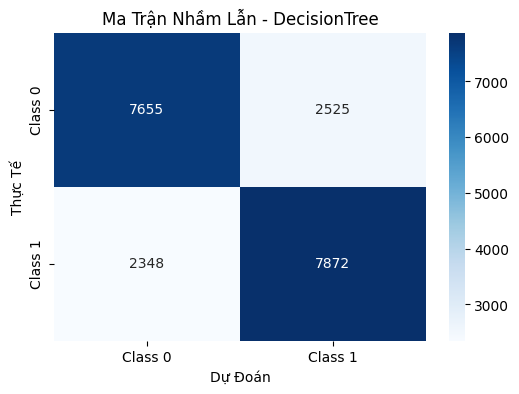

Báo cáo phân loại cho mô hình: LogisticRegression
              precision    recall  f1-score       support
0              0.738955  0.647348  0.690125  10180.000000
1              0.687337  0.772211  0.727306  10220.000000
accuracy       0.709902  0.709902  0.709902      0.709902
macro avg      0.713146  0.709780  0.708715  20400.000000
weighted avg   0.713095  0.709902  0.708752  20400.000000




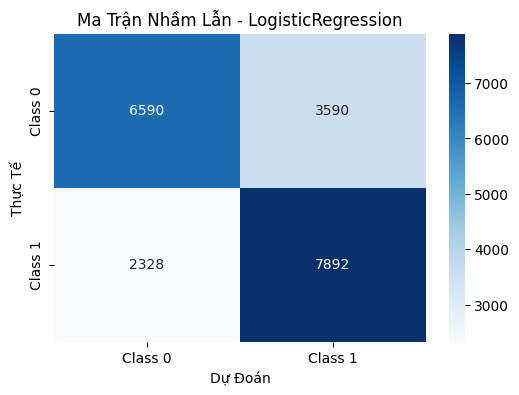

Báo cáo phân loại cho mô hình: KNeighbors
              precision    recall  f1-score       support
0              0.784880  0.693517  0.736375  10180.000000
1              0.726436  0.810665  0.766243  10220.000000
accuracy       0.752206  0.752206  0.752206      0.752206
macro avg      0.755658  0.752091  0.751309  20400.000000
weighted avg   0.755601  0.752206  0.751338  20400.000000




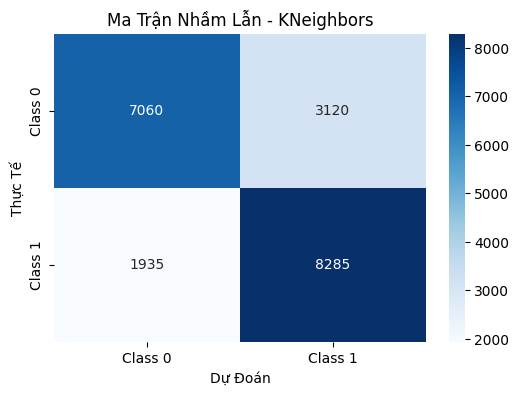

Chi tiết báo cáo phân loại cho mô hình: GaussianNB
              precision    recall  f1-score       support
Label                                                    
0              0.576620  0.891552  0.700309  10180.000000
1              0.763090  0.347945  0.477957  10220.000000
accuracy       0.619216  0.619216  0.619216      0.619216
macro avg      0.669855  0.619749  0.589133  20400.000000
weighted avg   0.670038  0.619216  0.588915  20400.000000
Chi tiết báo cáo phân loại cho mô hình: DecisionTree
              precision    recall  f1-score       support
Label                                                    
0              0.765270  0.751965  0.758559  10180.000000
1              0.757141  0.770254  0.763642  10220.000000
accuracy       0.761127  0.761127  0.761127      0.761127
macro avg      0.761206  0.761110  0.761100  20400.000000
weighted avg   0.761198  0.761127  0.761105  20400.000000
Chi tiết báo cáo phân loại cho mô hình: LogisticRegression
              precision  

In [ ]:
# Tạo một từ điển để lưu kết quả
model_reports = {}

# Huấn luyện và thu thập thông số
for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train, y_train)

    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)

    # Lấy báo cáo phân loại chi tiết
    report = classification_report(y_test, y_pred, output_dict=True)

    # Lưu báo cáo vào từ điển
    model_reports[name] = pd.DataFrame(report).T

    # In báo cáo
    print(f"Báo cáo phân loại cho mô hình: {name}")
    print(model_reports[name])
    print("\n")

    # Hiển thị ma trận nhầm lẫn
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Ma Trận Nhầm Lẫn - {name}')
    plt.xlabel('Dự Đoán')
    plt.ylabel('Thực Tế')
    plt.show()

# Hiển thị chi tiết báo cáo cho từng mô hình
for name, report_df in model_reports.items():
    # Chỉ lấy các chỉ số chính (precision, recall, f1-score, support)
    report_df = report_df[['precision', 'recall', 'f1-score', 'support']]
    report_df.index.name = 'Label'
    print(f"Chi tiết báo cáo phân loại cho mô hình: {name}")
    print(report_df)



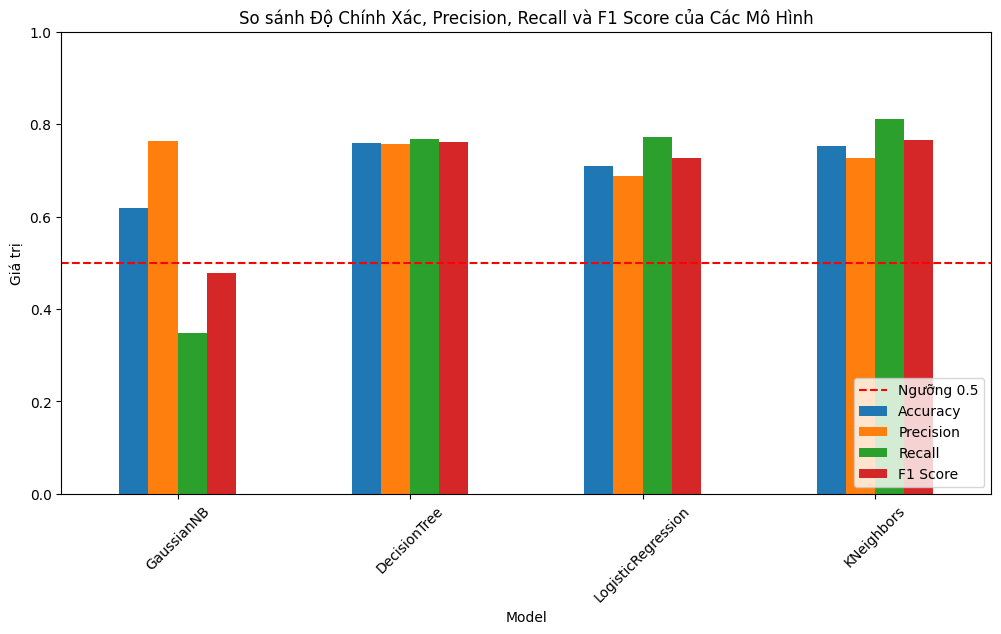

In [ ]:
# Tạo DataFrame từ kết quả chứa các chỉ số cho từng mô hình
metrics_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

# Biểu đồ cột - So sánh các chỉ số
metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('So sánh Độ Chính Xác, Precision, Recall và F1 Score của Các Mô Hình')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Đặt giới hạn trục y từ 0 đến 1
plt.axhline(0.5, color='red', linestyle='--', label='Ngưỡng 0.5')  # Đường ngưỡng
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Lấy mẫu 10 khách hàng từ dữ liệu kiểm tra
sample_customers = X_test.head(10)
sample_actual_labels = y_test.head(10)

# In thông tin mẫu dữ liệu
print("Dữ liệu thực tế của 10 khách hàng (nhãn thật):")
print(sample_actual_labels.values)
print("\n")

# Thực hiện dự đoán với từng mô hình
for name, model in models.items():
    # Dự đoán cho 10 khách hàng
    predictions = model.predict(sample_customers)

    # In kết quả dự đoán
    print(f"Dự đoán của mô hình {name} cho 10 khách hàng:")
    print(predictions)
    print("\n")

Dữ liệu thực tế của 10 khách hàng (nhãn thật):
[1 1 0 1 1 1 1 1 0 1]


Dự đoán của mô hình GaussianNB cho 10 khách hàng:
[0 0 0 0 0 0 0 0 0 0]


Dự đoán của mô hình DecisionTree cho 10 khách hàng:
[1 1 0 1 0 1 1 0 0 1]


Dự đoán của mô hình LogisticRegression cho 10 khách hàng:
[1 1 0 0 0 1 0 0 0 0]


Dự đoán của mô hình KNeighbors cho 10 khách hàng:
[1 1 0 1 1 1 1 1 0 1]




  Đầu ra nhận được là kết quả dự đoán của các mô hình cho 10 khách hàng đầu tiên từ tập kiểm tra (X_test). Kết quả được trình bày dưới dạng nhãn dự đoán (0 hoặc 1), trong đó:

- 0: Khách hàng không thực hiện hành vi "mua hàng" (không thuộc lớp purchase).
- 1: Khách hàng thực hiện hành vi "mua hàng" (thuộc lớp purchase).

Ý nghĩa của từng dòng:

GaussianNB:

- Tất cả 10 khách hàng đều được dự đoán không mua hàng (0). Điều này có thể cho thấy mô hình Gaussian Naive Bayes chưa học tốt hoặc thiếu thông tin cần thiết để phân biệt các lớp trong tập dữ liệu.

DecisionTree:

- Mô hình Decision Tree dự đoán có sự đa dạng hơn:
Một số khách hàng được dự đoán sẽ mua hàng (1), ví dụ như khách hàng số 2, 4, 6.
Một số khách hàng khác không mua hàng (0), ví dụ như khách hàng số 3, 5, 8.
Điều này cho thấy mô hình có khả năng phân biệt tốt hơn dựa trên dữ liệu.

LogisticRegression:

- Logistic Regression cũng đưa ra dự đoán hỗn hợp nhưng có vẻ thận trọng hơn khi chỉ một số ít khách hàng được dự đoán mua hàng (1), như khách hàng số 1, 2, và 6.

KNeighbors:

- Mô hình K-Nearest Neighbors dự đoán nhiều khách hàng mua hàng hơn so với Logistic Regression, như khách hàng số 1, 2, 4, 5, 6, và 8.
